# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  878M    0  878M    0     0  4846k      0 --:--:--  0:03:05 --:--:-- 3617k


In [10]:
!rm SUSY.csv

rm: SUSY.csv: No such file or directory


In [12]:
!gunzip SUSY.csv.gz

gunzip: SUSY.csv.gz: unexpected end of file
gunzip: SUSY.csv.gz: uncompress failed


In [4]:
ls -lh

total 1816256
-rw-r--r--  1 jasemcada  staff   389K Mar 18 15:05 Lab.7.ipynb
-rw-r--r--  1 jasemcada  staff   5.8M Mar 18 15:05 Lab.7.pdf
-rw-r--r--@ 1 jasemcada  staff   389K Mar 20 13:57 Lab.7.solution.ipynb
-rw-r--r--  1 jasemcada  staff   878M Mar 20 13:55 SUSY.csv.gz


In [1]:
!ls -lh SUSY.csv

-rw-r--r--  1 jasemcada  staff   2.2G Mar 20 14:05 SUSY.csv


In [ ]:
## GOOD- Don't Rerun

The data is provided as a comma separated file.

In [2]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [1]:
!ls -lh SUSY.csv

-rw-r--r--  1 jasemcada  staff   2.2G Mar 26 13:14 SUSY.csv


In [2]:
!ls -lh

total 4686400
-rw-r--r--  1 jasemcada  staff   401K Mar 26 13:13 Lab.7.ipynb
-rw-r--r--  1 jasemcada  staff   8.0M Mar 26 13:13 Lab.7.pdf
-rw-r--r--@ 1 jasemcada  staff   390K Mar 26 13:14 Lab.7.solution.ipynb
-rw-r--r--  1 jasemcada  staff   2.2G Mar 26 13:14 SUSY.csv


We see that we have 5 million datapoints.

In [3]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [4]:
!head -500000 SUSY.csv > SUSY-small.csv

In [5]:
ls -lh

total 5153256
-rw-r--r--  1 jasemcada  staff   401K Mar 26 13:13 Lab.7.ipynb
-rw-r--r--  1 jasemcada  staff   8.0M Mar 26 13:13 Lab.7.pdf
-rw-r--r--@ 1 jasemcada  staff   390K Mar 26 13:14 Lab.7.solution.ipynb
-rw-r--r--  1 jasemcada  staff   228M Mar 26 14:47 SUSY-small.csv
-rw-r--r--  1 jasemcada  staff   2.2G Mar 26 13:14 SUSY.csv


In [6]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [1]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [2]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [3]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [4]:
FeatureNames

['cos_theta_r1',
 'M_TR_2',
 'MT2',
 'axial_MET',
 'R',
 'S_R',
 'MET_rel',
 'M_R',
 'dPhi_r_b',
 'M_Delta_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [6]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [7]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [8]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


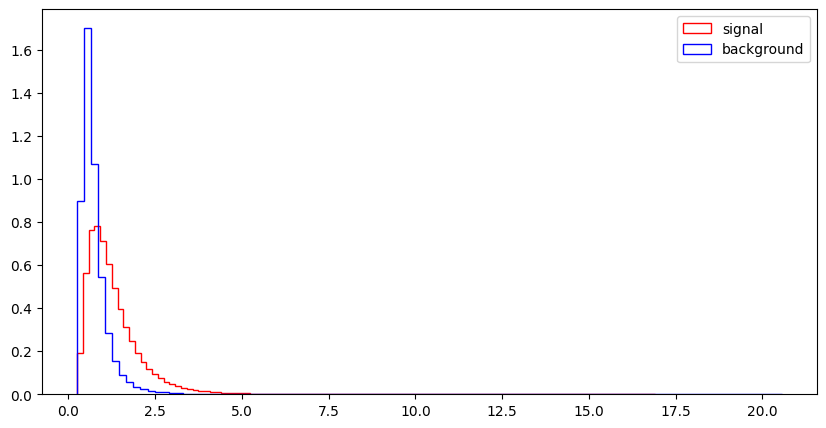

l_1_eta


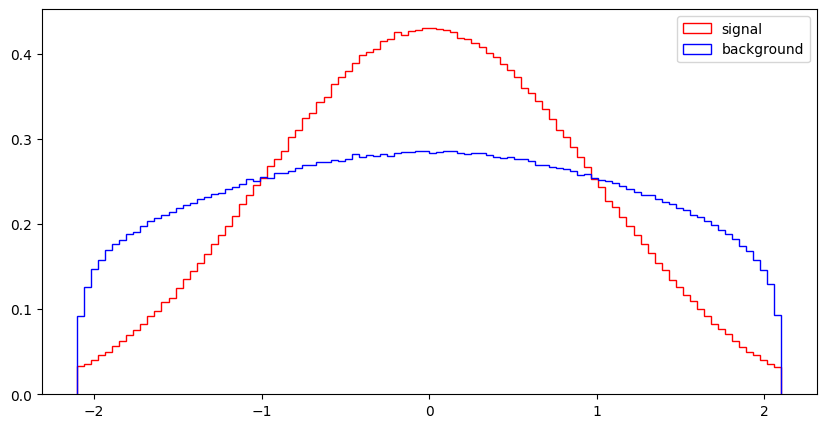

l_1_phi


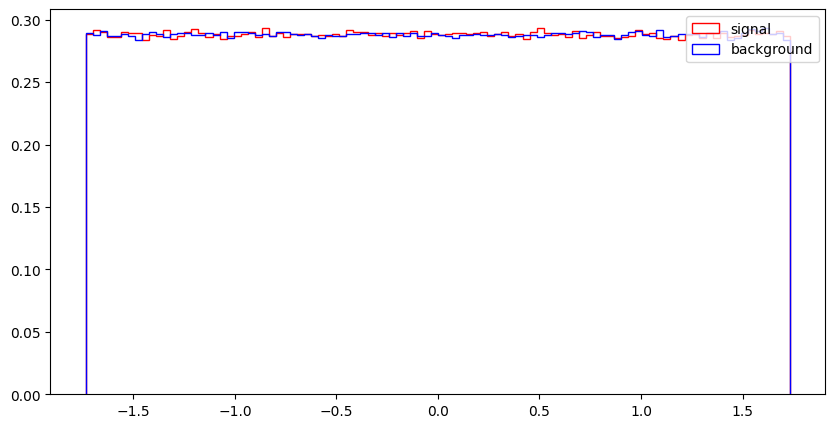

l_2_pT


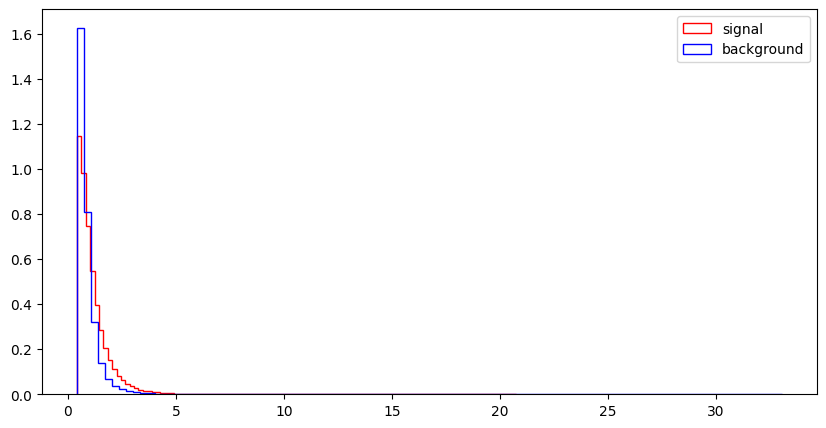

l_2_eta


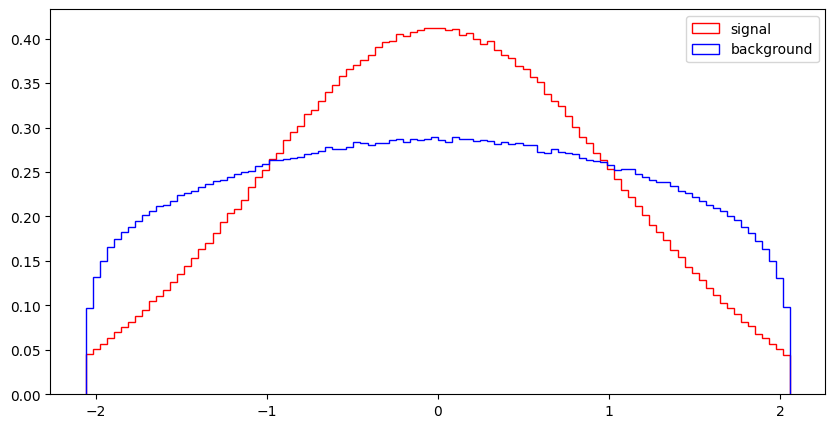

l_2_phi


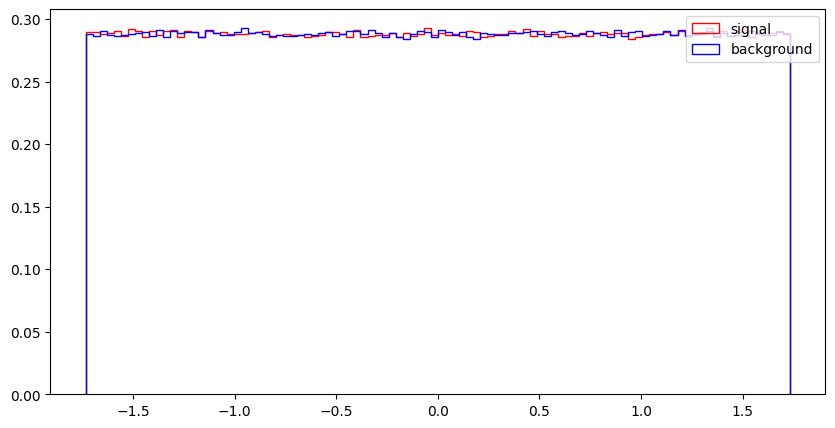

MET


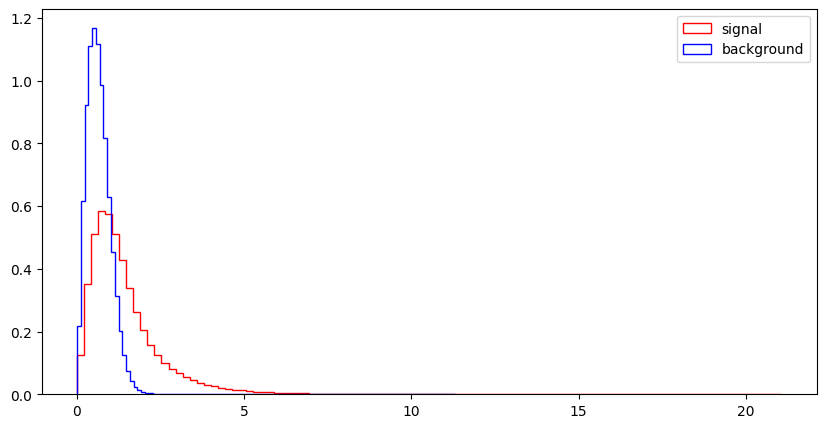

MET_phi


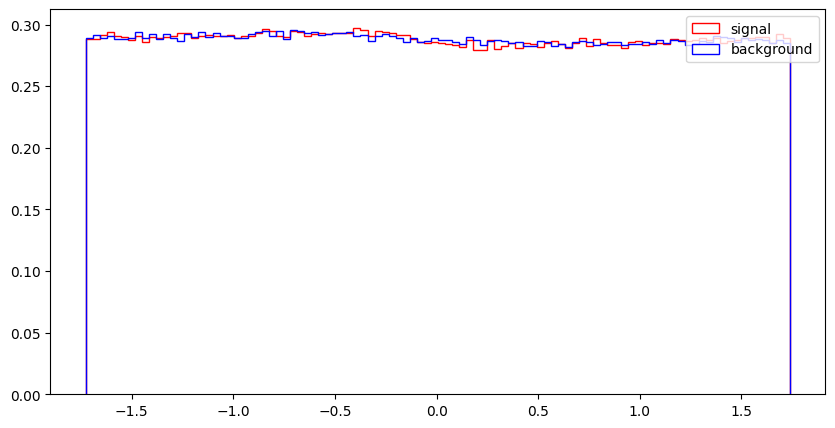

MET_rel


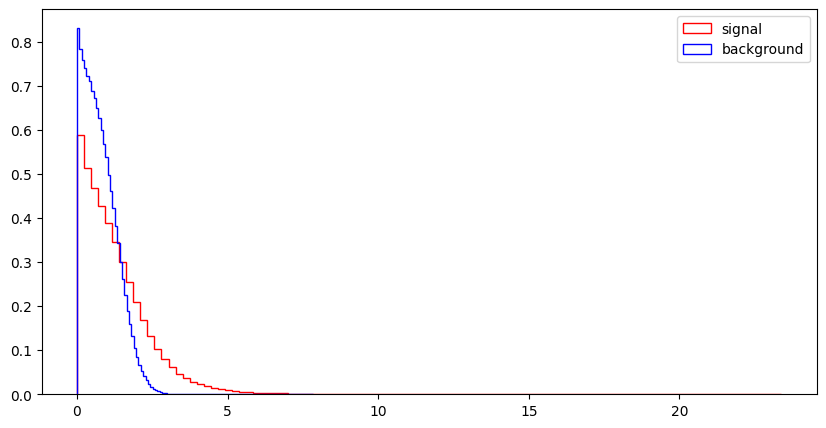

axial_MET


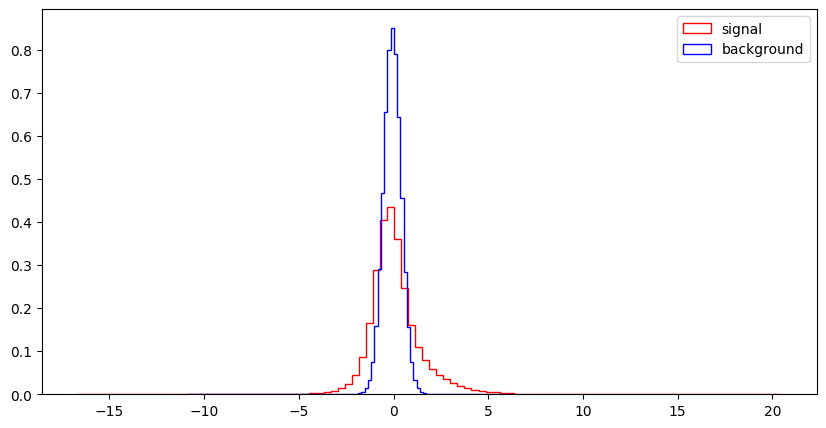

M_R


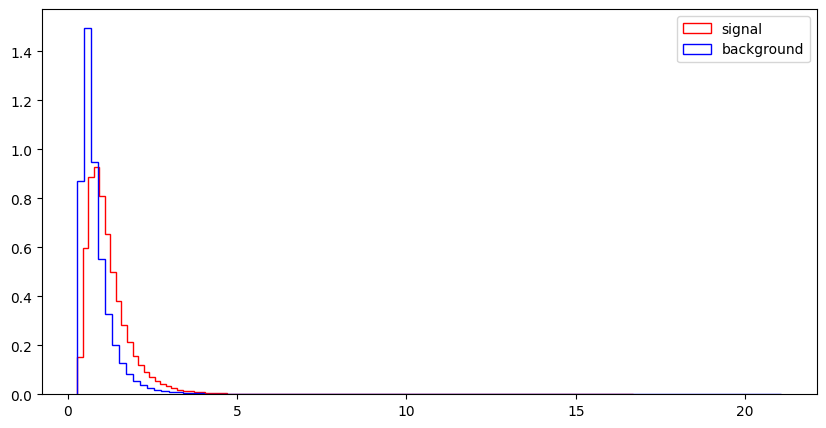

M_TR_2


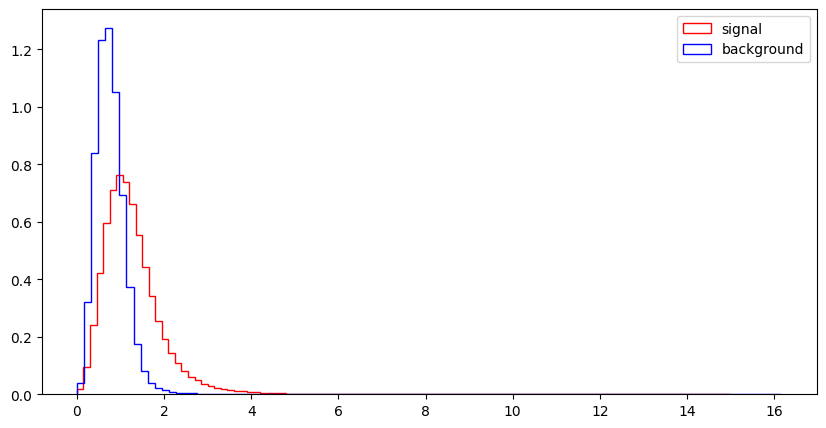

R


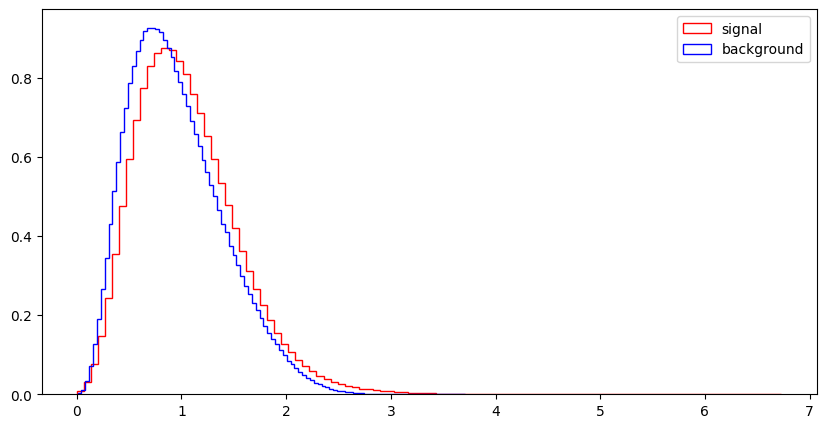

MT2


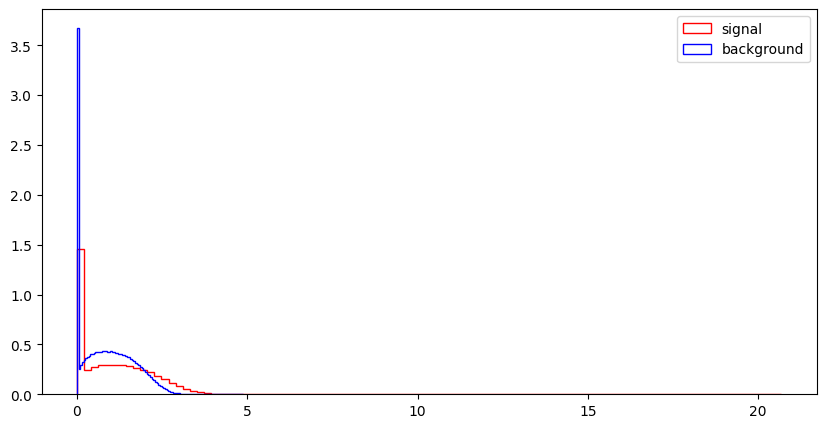

S_R


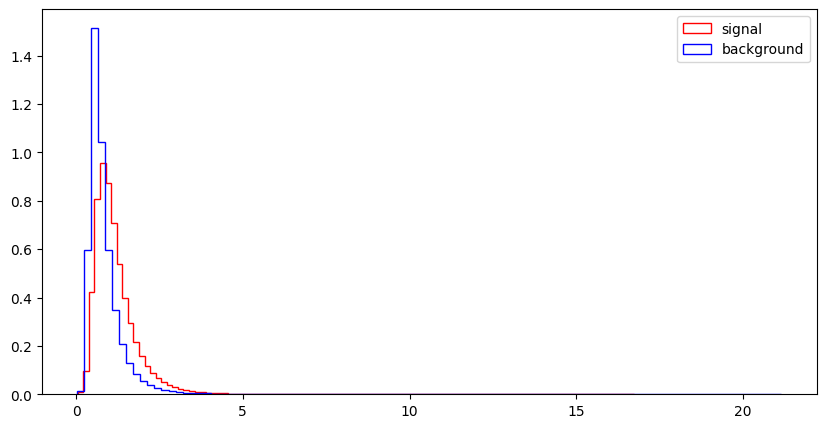

M_Delta_R


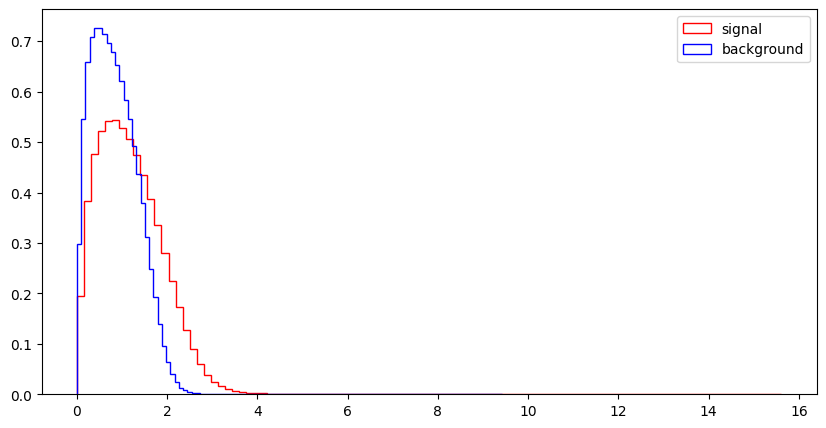

dPhi_r_b


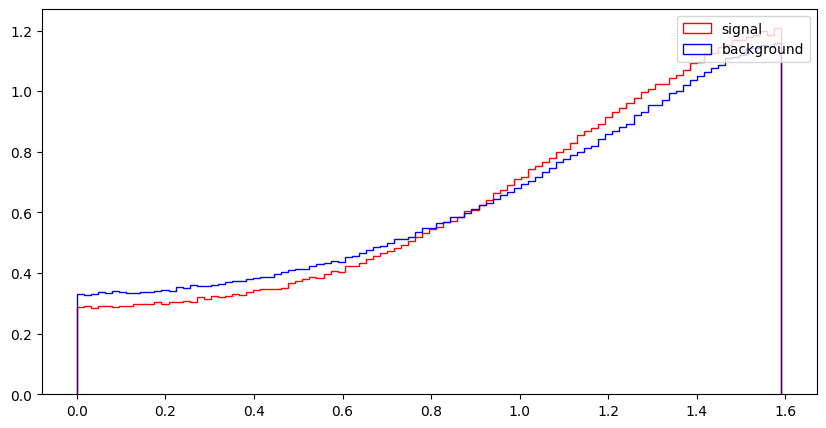

cos_theta_r1


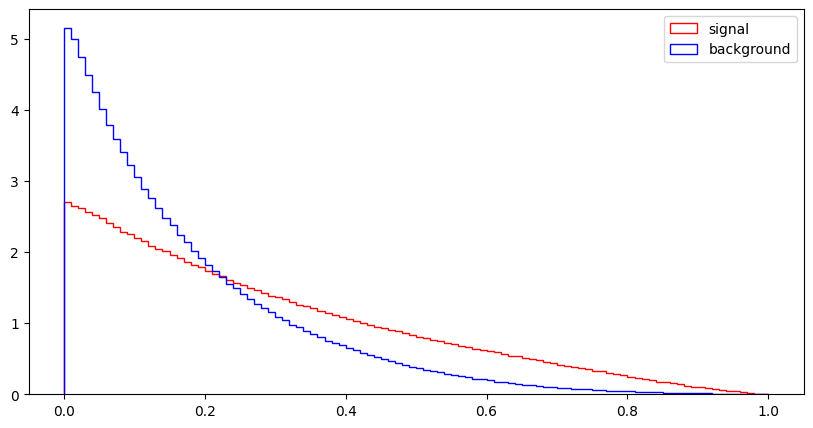

In [9]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

In [10]:
print(df.columns)

Index(['signal', 'l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta',
       'l_2_phi', 'MET', 'MET_phi', 'MET_rel', 'axial_MET', 'M_R', 'M_TR_2',
       'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1'],
      dtype='object')


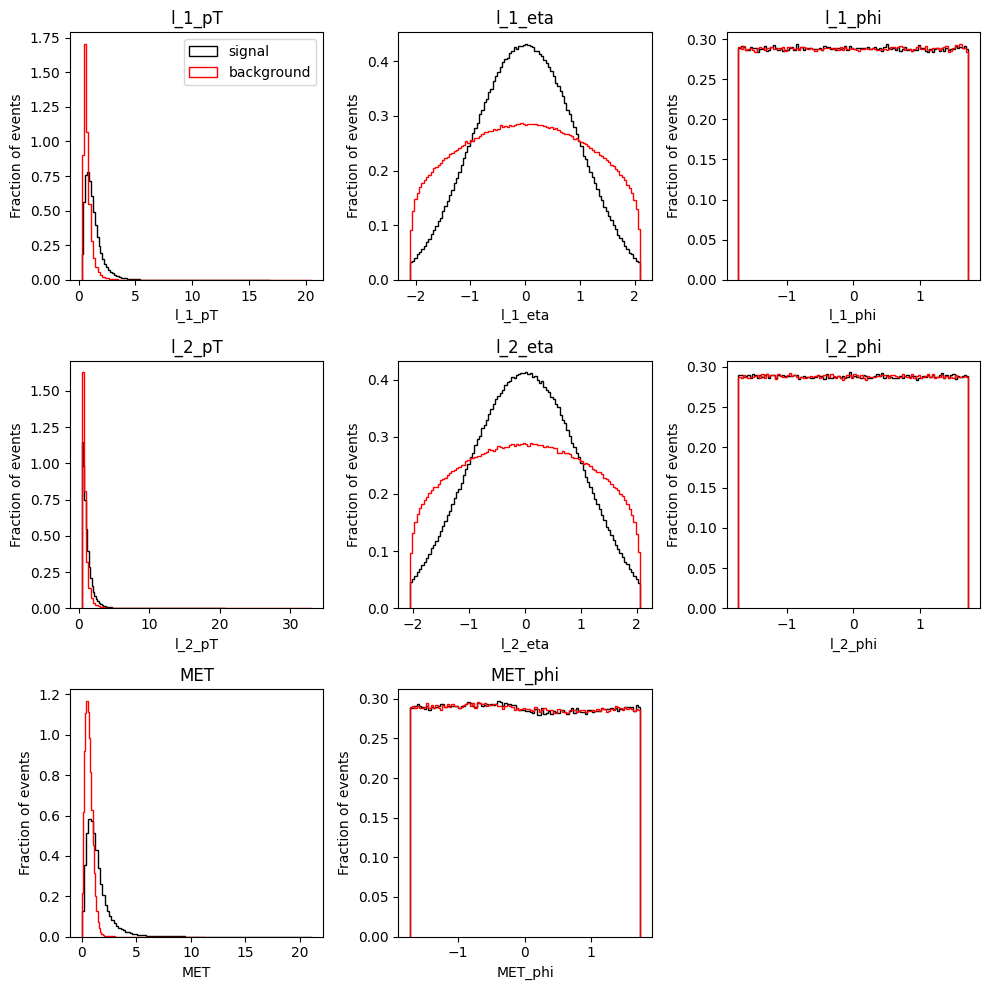

In [11]:
# Exercise 3: Low-level input features (similar to Figure 5)

# List of low-level variables to plot (using exact column names)
low_level_vars = ['l_1_pT', 'l_1_eta', 'l_1_phi',
                  'l_2_pT', 'l_2_eta', 'l_2_phi',
                  'MET', 'MET_phi']

# Create a new figure
plt.figure(figsize=(10, 10))

# Loop over low-level variables and make subplots
for i, var in enumerate(low_level_vars):
    # Select subplot position in a 3x3 grid
    plt.subplot(3, 3, i + 1)
    
    # Plot signal distribution
    plt.hist(np.array(df_sig[var]), bins=100, histtype='step',
             color='black', density=1, label='signal')
    
    # Plot background distribution
    plt.hist(np.array(df_bkg[var]), bins=100, histtype='step',
             color='red', density=1, label='background')
    
    # Label axes and add a simple title
    plt.xlabel(var)
    plt.ylabel('Fraction of events')
    plt.title(var)
    
    # Only draw legend once (on the first subplot)
    if i == 0:
        plt.legend(loc='upper right')

# Adjust layout so labels do not overlap
plt.tight_layout()
plt.show()

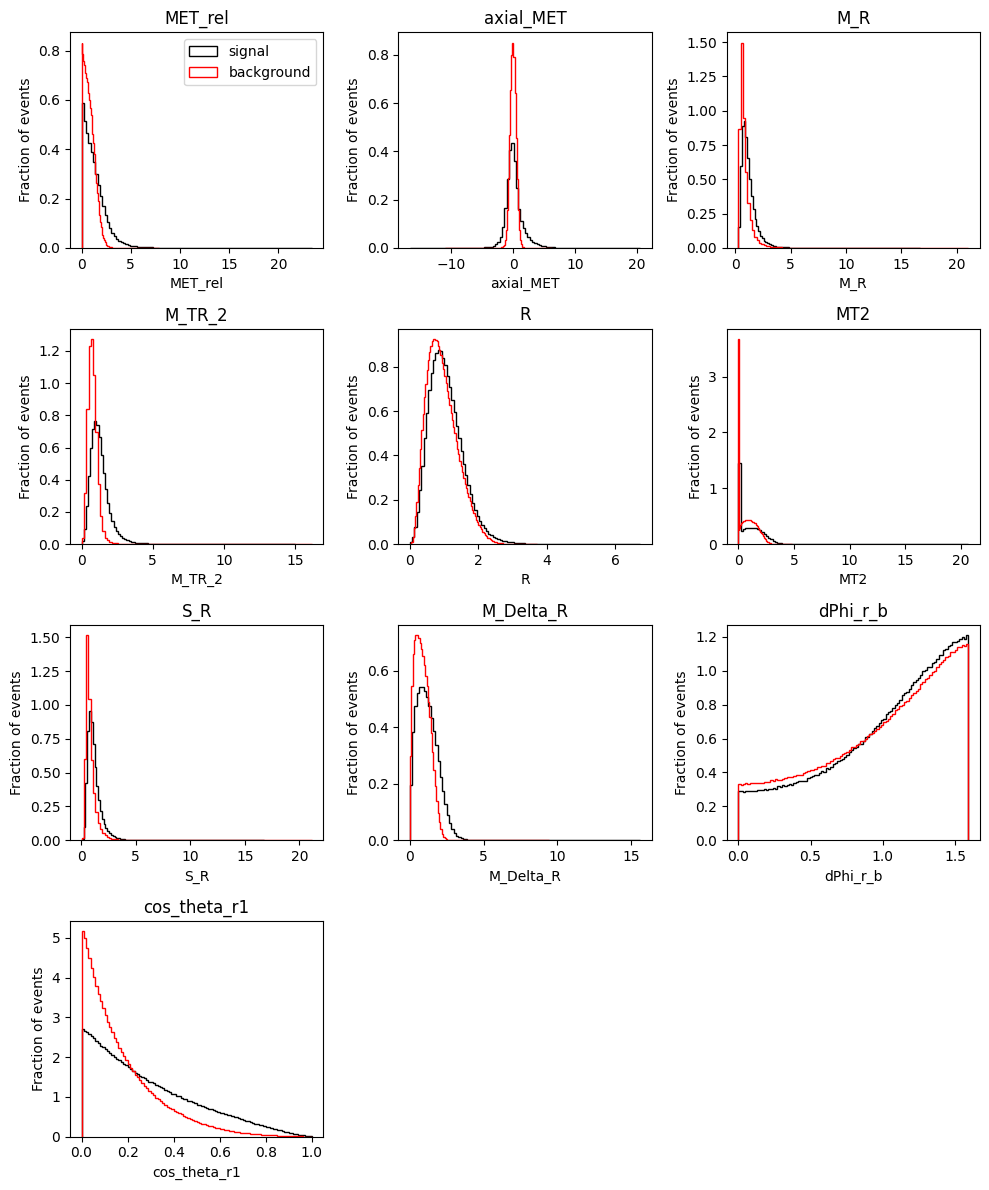

In [12]:
# Exercise 3: High-level input features (similar to Figure 6)

# List of high-level variables to plot (using exact column names)
high_level_vars = ['MET_rel', 'axial_MET', 'M_R', 'M_TR_2',
                   'R', 'MT2', 'S_R', 'M_Delta_R',
                   'dPhi_r_b', 'cos_theta_r1']

# Create a new figure
plt.figure(figsize=(10, 12))

# Loop over high-level variables and make subplots
for i, var in enumerate(high_level_vars):
    # Select subplot position in a 4x3 grid
    plt.subplot(4, 3, i + 1)
    
    # Plot signal distribution
    plt.hist(np.array(df_sig[var]), bins=100, histtype='step',
             color='black', density=1, label='signal')
    
    # Plot background distribution
    plt.hist(np.array(df_bkg[var]), bins=100, histtype='step',
             color='red', density=1, label='background')
    
    # Label axes and add a simple title
    plt.xlabel(var)
    plt.ylabel('Fraction of events')
    plt.title(var)
    
    # Only draw legend once (on the first subplot)
    if i == 0:
        plt.legend(loc='upper right')

# Adjust layout so labels do not overlap
plt.tight_layout()
plt.show()


## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

Using columns: ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta']


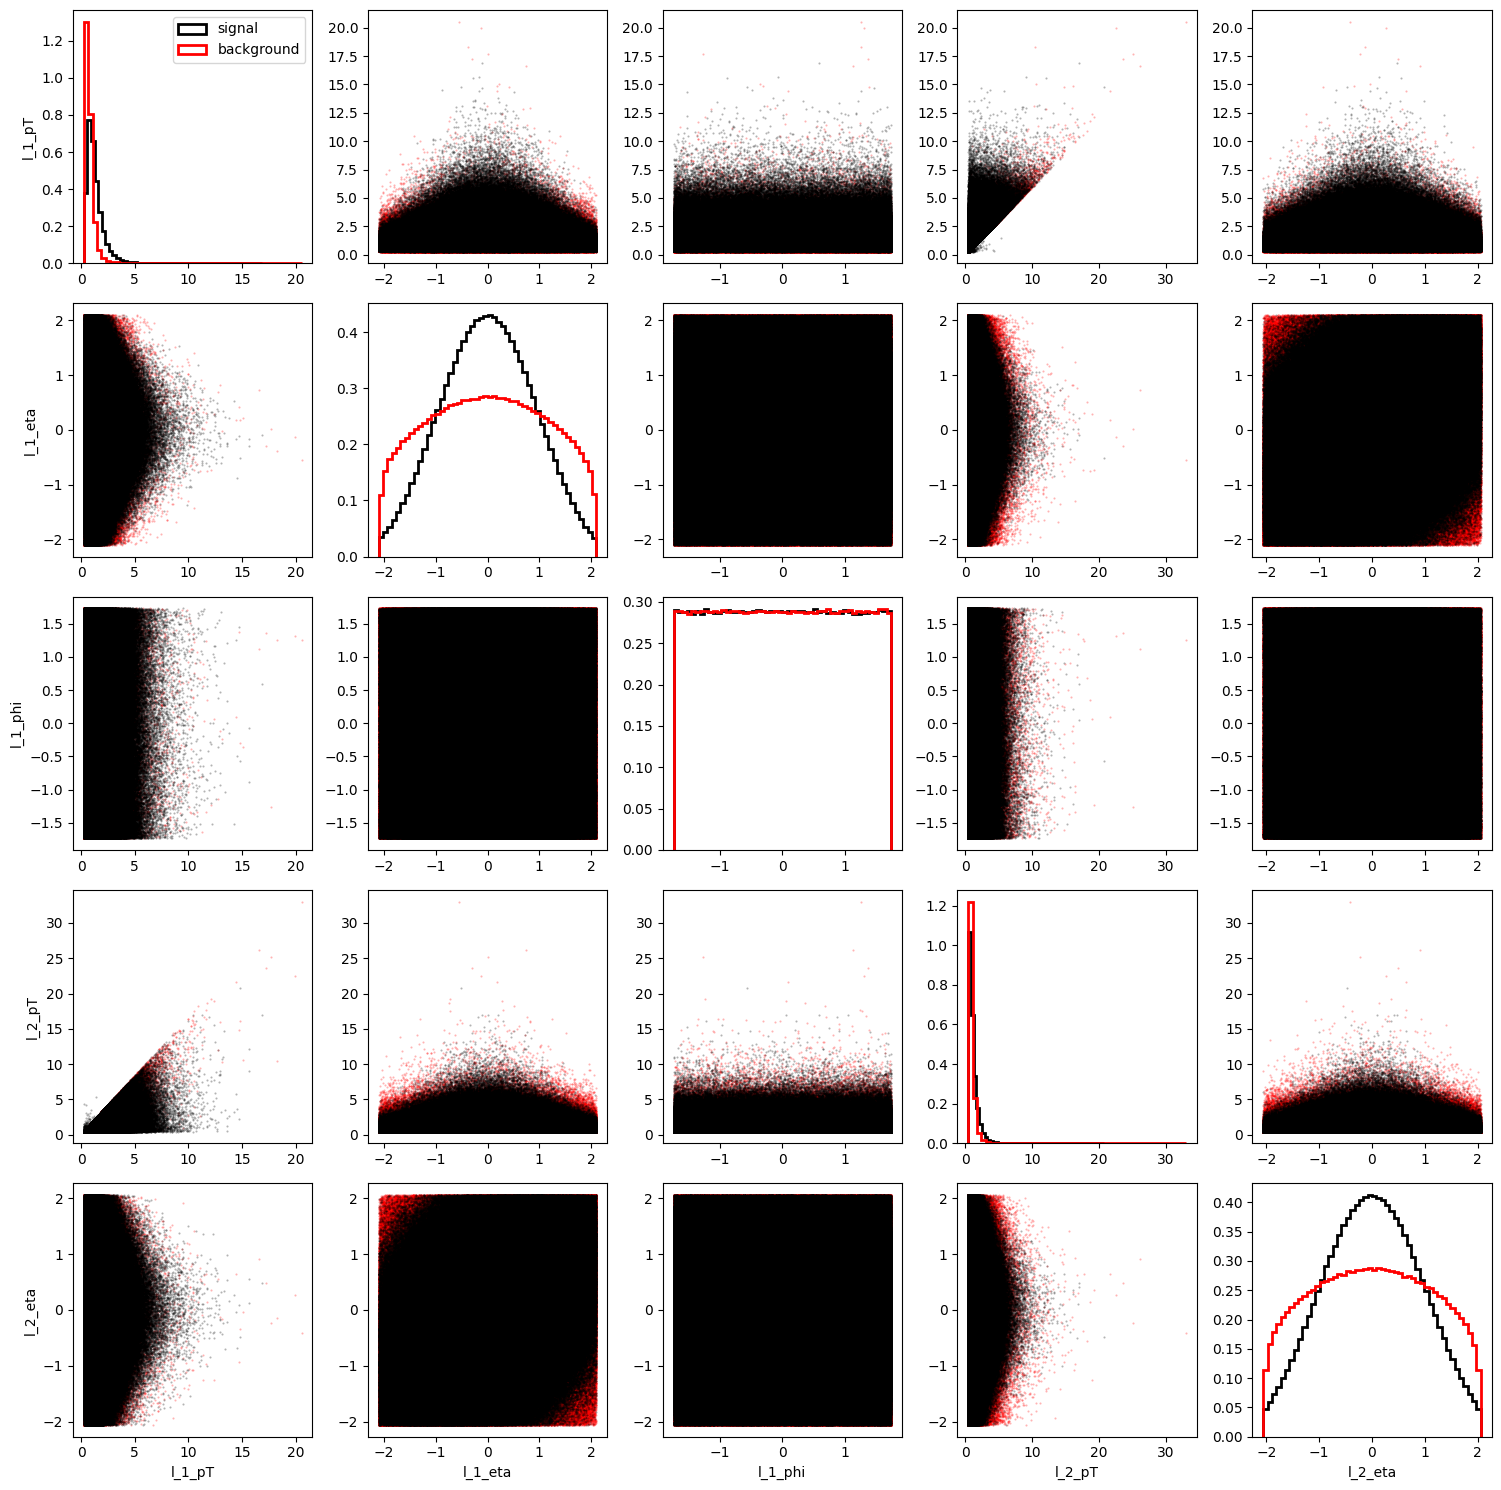

In [13]:
# Part A

# Use first 5 non-signal columns
columns = df.columns[1:6]  
print("Using columns:", columns.tolist())
n_columns = len(columns)

# Create figure
plt.figure(figsize=(15,15))

plot_i = 0
for i, x_var_name in enumerate(columns):
    for j, y_var_name in enumerate(columns):
        plot_i += 1
        plt.subplot(n_columns, n_columns, plot_i)
        make_legend = plot_i == 1
        
        if i == j:
            # Diagonal: histograms (signal vs background)
            plt.hist(np.array(df_sig[x_var_name]), bins=50, histtype='step',
                     color='black', density=1, label='signal', linewidth=2)
            plt.hist(np.array(df_bkg[x_var_name]), bins=50, histtype='step',
                     color='red', density=1, label='background', linewidth=2)
        else:
            # Off-diagonal: scatter plots (signal vs background)
            plt.plot(df_bkg[y_var_name], df_bkg[x_var_name], 'r.', markersize=1, alpha=0.3)
            plt.plot(df_sig[y_var_name], df_sig[x_var_name], 'k.', markersize=1, alpha=0.3)
        
        # Only label axes on edges
        if i == n_columns - 1:
            plt.xlabel(y_var_name)
        if j == 0:
            plt.ylabel(x_var_name)
        
        # Legend only on first plot 
        if make_legend:
            plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Using columns: ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta']


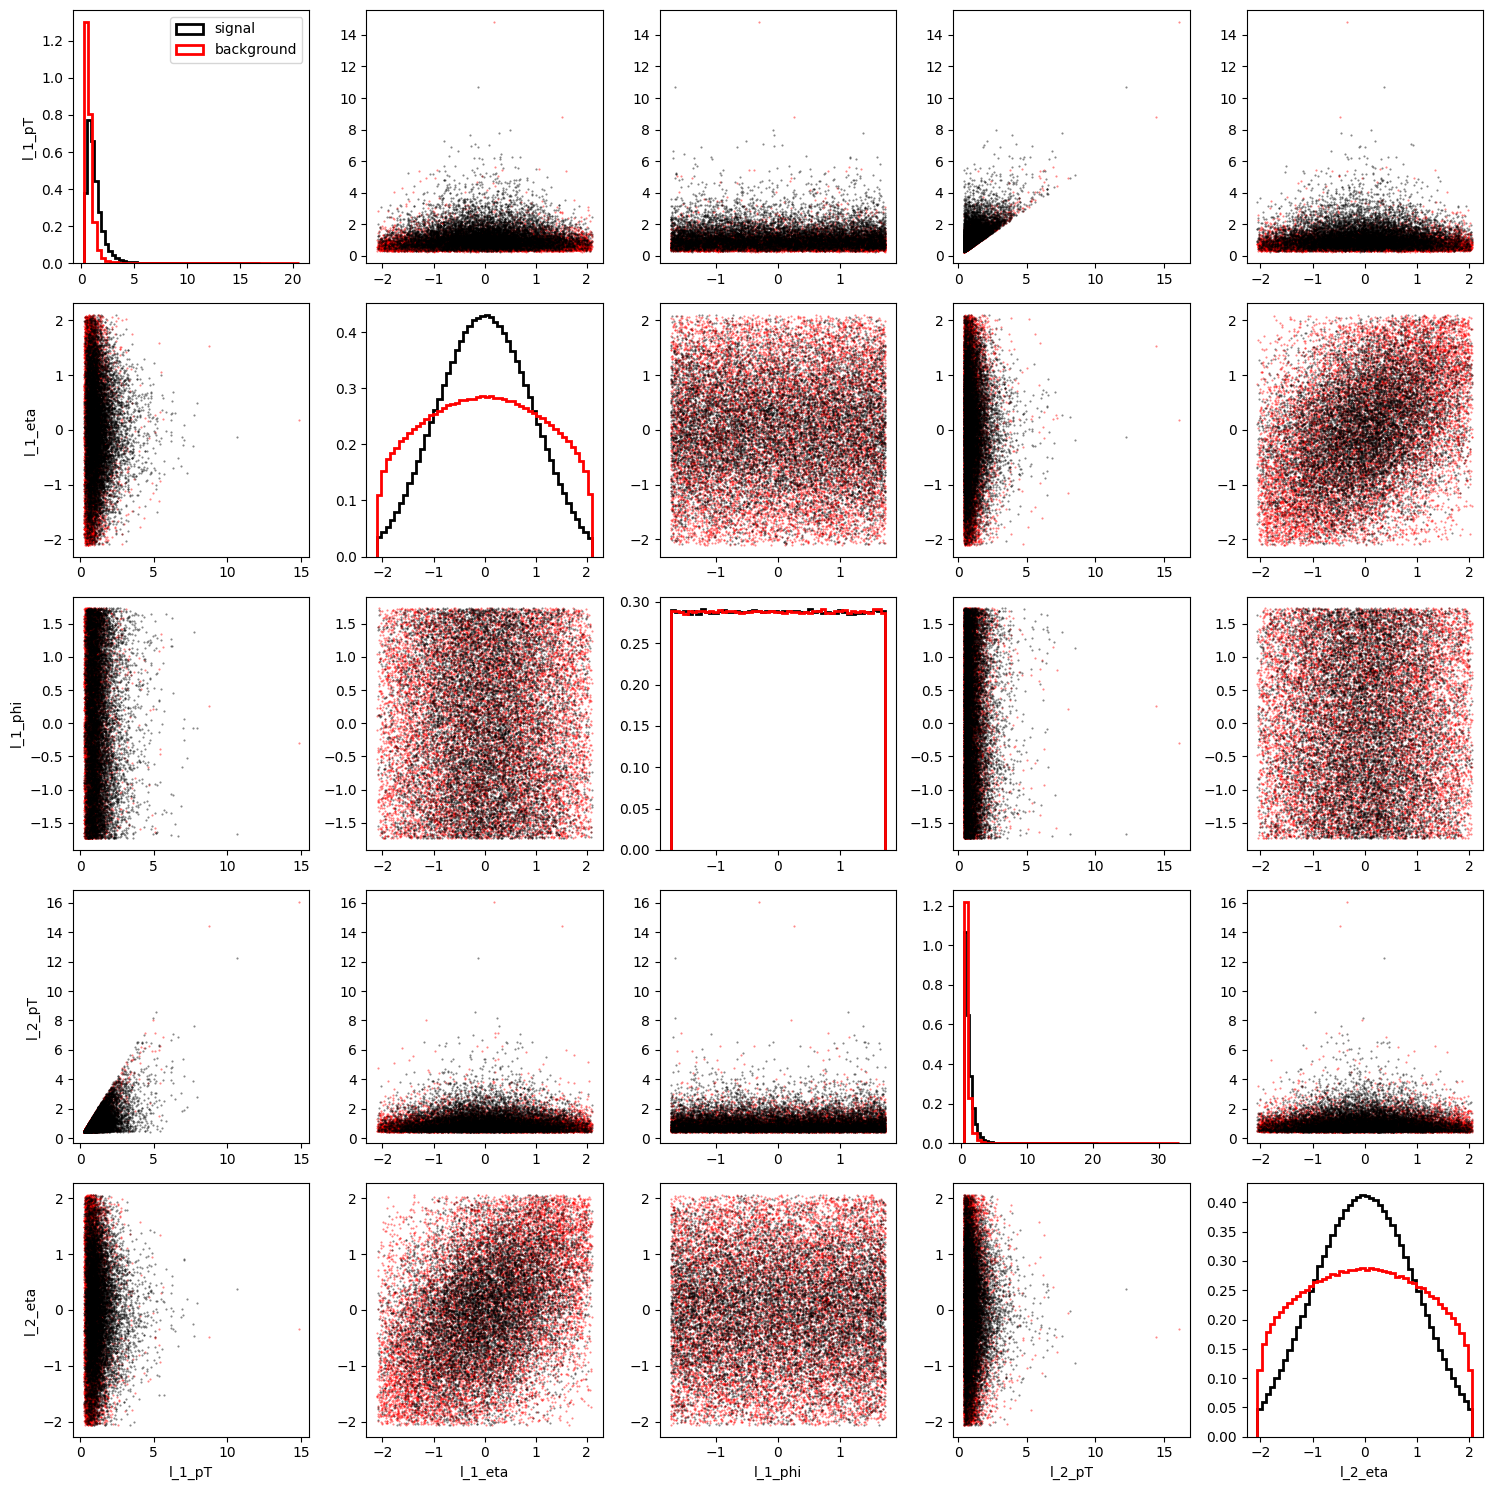

In [14]:
# Use first 5 non-signal columns, exactly like lecture
columns = df.columns[1:6]  
print("Using columns:", columns.tolist())
n_columns = len(columns)

# MODIFICATION: Downsample ONCE before the double loop (big speedup)
n_sample = 20000  # Use only 20k events total instead of 500k
df_sig_sample = df_sig.sample(n=n_sample//2, random_state=42)
df_bkg_sample = df_bkg.sample(n=n_sample//2, random_state=42)

# Create figure (same size as lecture)
plt.figure(figsize=(15,15))

plot_i = 0
for i, x_var_name in enumerate(columns):
    for j, y_var_name in enumerate(columns):
        plot_i += 1
        plt.subplot(n_columns, n_columns, plot_i)
        make_legend = plot_i == 1
        
        if i == j:
            # Diagonal: histograms using FULL data (still fast)
            plt.hist(np.array(df_sig[x_var_name]), bins=50, histtype='step',
                     color='black', density=1, label='signal', linewidth=2)
            plt.hist(np.array(df_bkg[x_var_name]), bins=50, histtype='step',
                     color='red', density=1, label='background', linewidth=2)
        else:
            # Off-diagonal: scatter using SAMPLED data (much faster)
            plt.plot(df_bkg_sample[y_var_name], df_bkg_sample[x_var_name], 
                    'r.', markersize=1, alpha=0.5)
            plt.plot(df_sig_sample[y_var_name], df_sig_sample[x_var_name], 
                    'k.', markersize=1, alpha=0.5)
        
        # Only label axes on edges (lecture style)
        if i == n_columns - 1:
            plt.xlabel(y_var_name)
        if j == 0:
            plt.ylabel(x_var_name)
        
        # Legend only on first plot
        if make_legend:
            plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [22]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [15]:
all_vars = ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta', 
            'l_2_phi', 'MET', 'MET_phi', 'MET_rel', 'axial_MET', 
            'M_R', 'M_TR_2', 'R', 'MT2', 'S_R', 'M_Delta_R', 
            'dPhi_r_b', 'cos_theta_r1']

low_vars = ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta', 
            'l_2_phi', 'MET', 'MET_phi']

high_vars = ['MET_rel', 'axial_MET', 'M_R', 'M_TR_2', 'R', 'MT2', 
             'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1']

# Get data for each group
data_all = df[all_vars].to_numpy()
data_low = df[low_vars].to_numpy()
data_high = df[high_vars].to_numpy()

# Compute covariance and correlation matrices
cov_all = np.cov(data_all, rowvar=False)
corr_all = np.corrcoef(data_all, rowvar=False)

cov_low = np.cov(data_low, rowvar=False)
corr_low = np.corrcoef(data_low, rowvar=False)

cov_high = np.cov(data_high, rowvar=False)
corr_high = np.corrcoef(data_high, rowvar=False)

In [16]:
from IPython.display import HTML, display
import tabulate

# Function to make and display one matrix table
def show_matrix(matrix, headers, title):
    table = tabulate.tabulate(matrix, headers=headers, floatfmt=".3f", tablefmt="html")
    display(HTML(f"<h3>{title}</h3>" + table))

# Show all three covariance matrices
show_matrix(cov_all, all_vars, "All Variables - Covariance")
show_matrix(cov_low, low_vars, "Low-level Variables - Covariance") 
show_matrix(cov_high, high_vars, "High-level Variables - Covariance")

# Show all three correlation matrices  
show_matrix(corr_all, all_vars, "All Variables - Correlation")
show_matrix(corr_low, low_vars, "Low-level Variables - Correlation")
show_matrix(corr_high, high_vars, "High-level Variables - Correlation")


l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0.472,-0.000,-0.000,0.308,-0.000,0.000,0.231,-0.001,0.099,-0.013,0.368,0.291,-0.059,-0.013,0.346,0.098,-0.047,0.023
-0.000,1.006,0.000,-0.000,0.406,0.000,-0.001,-0.001,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.001,0.000,0.000
-0.000,0.000,1.003,-0.000,0.001,-0.268,0.001,-0.184,0.002,-0.002,-0.000,0.001,0.001,0.002,0.000,0.001,0.001,0.000
0.308,-0.000,-0.000,0.428,-0.000,0.000,0.080,-0.001,-0.002,0.050,0.328,0.164,-0.099,-0.069,0.325,0.006,-0.004,-0.028
-0.000,0.406,0.001,-0.000,1.006,-0.000,0.000,-0.000,0.000,-0.000,-0.001,-0.000,0.000,-0.000,-0.001,-0.000,-0.000,0.000
0.000,0.000,-0.268,0.000,-0.000,1.003,0.000,-0.034,0.000,-0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.000,-0.000
0.231,-0.001,0.001,0.080,0.000,0.000,0.762,-0.002,0.548,0.145,0.146,0.368,0.189,0.156,0.167,0.317,0.145,0.073
-0.001,-0.001,-0.184,-0.001,-0.000,-0.034,-0.002,1.003,-0.003,-0.001,-0.001,-0.001,-0.000,0.001,-0.001,-0.000,-0.001,0.000
0.099,-0.000,0.002,-0.002,0.000,0.000,0.548,-0.003,0.792,-0.125,0.044,0.303,0.250,0.410,0.082,0.416,0.147,0.056
-0.013,-0.000,-0.002,0.050,-0.000,-0.000,0.145,-0.001,-0.125,1.003,0.015,-0.189,-0.182,-0.460,-0.043,-0.234,-0.026,-0.054


l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
0.472,-0.000,-0.000,0.308,-0.000,0.000,0.231,-0.001
-0.000,1.006,0.000,-0.000,0.406,0.000,-0.001,-0.001
-0.000,0.000,1.003,-0.000,0.001,-0.268,0.001,-0.184
0.308,-0.000,-0.000,0.428,-0.000,0.000,0.080,-0.001
-0.000,0.406,0.001,-0.000,1.006,-0.000,0.000,-0.000
0.000,0.000,-0.268,0.000,-0.000,1.003,0.000,-0.034
0.231,-0.001,0.001,0.080,0.000,0.000,0.762,-0.002
-0.001,-0.001,-0.184,-0.001,-0.000,-0.034,-0.002,1.003


MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0.792,-0.125,0.044,0.303,0.250,0.410,0.082,0.416,0.147,0.056
-0.125,1.003,0.015,-0.189,-0.182,-0.460,-0.043,-0.234,-0.026,-0.054
0.044,0.015,0.395,0.212,-0.113,-0.037,0.383,0.074,-0.029,-0.014
0.303,-0.189,0.212,0.341,0.104,0.189,0.230,0.242,0.058,0.052
0.250,-0.182,-0.113,0.104,0.222,0.232,-0.083,0.166,0.087,0.058
0.410,-0.460,-0.037,0.189,0.232,0.738,-0.011,0.433,0.021,0.045
0.082,-0.043,0.383,0.230,-0.083,-0.011,0.385,0.096,-0.004,-0.010
0.416,-0.234,0.074,0.242,0.166,0.433,0.096,0.389,0.042,0.039
0.147,-0.026,-0.029,0.058,0.087,0.021,-0.004,0.042,0.190,0.009
0.056,-0.054,-0.014,0.052,0.058,0.045,-0.010,0.039,0.009,0.039


l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
1.000,-0.000,-0.000,0.685,-0.000,0.000,0.385,-0.001,0.161,-0.018,0.852,0.724,-0.183,-0.022,0.812,0.229,-0.157,0.166
-0.000,1.000,0.000,-0.001,0.403,0.000,-0.001,-0.001,-0.001,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.001,0.000,0.001
-0.000,0.000,1.000,-0.000,0.001,-0.267,0.001,-0.184,0.002,-0.002,-0.000,0.001,0.002,0.002,0.000,0.002,0.002,0.002
0.685,-0.001,-0.000,1.000,-0.001,0.000,0.140,-0.002,-0.004,0.076,0.798,0.430,-0.322,-0.123,0.799,0.014,-0.014,-0.216
-0.000,0.403,0.001,-0.001,1.000,-0.000,0.000,-0.000,0.000,-0.000,-0.001,-0.000,0.001,-0.000,-0.001,-0.000,-0.000,0.001
0.000,0.000,-0.267,0.000,-0.000,1.000,0.000,-0.034,0.000,-0.000,0.000,0.000,0.000,0.001,0.001,0.001,0.001,-0.001
0.385,-0.001,0.001,0.140,0.000,0.000,1.000,-0.002,0.706,0.166,0.266,0.722,0.459,0.209,0.309,0.581,0.382,0.426
-0.001,-0.001,-0.184,-0.002,-0.000,-0.034,-0.002,1.000,-0.003,-0.001,-0.002,-0.001,-0.000,0.001,-0.002,-0.001,-0.003,0.000
0.161,-0.001,0.002,-0.004,0.000,0.000,0.706,-0.003,1.000,-0.141,0.078,0.583,0.595,0.536,0.149,0.749,0.378,0.317
-0.018,-0.000,-0.002,0.076,-0.000,-0.000,0.166,-0.001,-0.141,1.000,0.024,-0.323,-0.385,-0.535,-0.070,-0.375,-0.060,-0.274


l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
1.000,-0.000,-0.000,0.685,-0.000,0.000,0.385,-0.001
-0.000,1.000,0.000,-0.001,0.403,0.000,-0.001,-0.001
-0.000,0.000,1.000,-0.000,0.001,-0.267,0.001,-0.184
0.685,-0.001,-0.000,1.000,-0.001,0.000,0.140,-0.002
-0.000,0.403,0.001,-0.001,1.000,-0.000,0.000,-0.000
0.000,0.000,-0.267,0.000,-0.000,1.000,0.000,-0.034
0.385,-0.001,0.001,0.140,0.000,0.000,1.000,-0.002
-0.001,-0.001,-0.184,-0.002,-0.000,-0.034,-0.002,1.000


MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
1.000,-0.141,0.078,0.583,0.595,0.536,0.149,0.749,0.378,0.317
-0.141,1.000,0.024,-0.323,-0.385,-0.535,-0.070,-0.375,-0.060,-0.274
0.078,0.024,1.000,0.578,-0.381,-0.068,0.981,0.189,-0.106,-0.115
0.583,-0.323,0.578,1.000,0.380,0.378,0.636,0.666,0.228,0.451
0.595,-0.385,-0.381,0.380,1.000,0.574,-0.285,0.564,0.424,0.627
0.536,-0.535,-0.068,0.378,0.574,1.000,-0.021,0.808,0.056,0.263
0.149,-0.070,0.981,0.636,-0.285,-0.021,1.000,0.248,-0.013,-0.084
0.749,-0.375,0.189,0.666,0.564,0.808,0.248,1.000,0.156,0.319
0.378,-0.060,-0.106,0.228,0.424,0.056,-0.013,0.156,1.000,0.106
0.317,-0.274,-0.115,0.451,0.627,0.263,-0.084,0.319,0.106,1.000


In [40]:
def analyze_cov_corr(df_in, col_list, name=""):
    # Get data
    data = df_in[col_list].to_numpy()
    
    # Compute matrices
    cov = np.cov(data, rowvar=False)
    corr = np.corrcoef(data, rowvar=False)
    
    # Show tables
    show_matrix(cov, col_list, f"{name} - Covariance")
    show_matrix(corr, col_list, f"{name} - Correlation")
    
    return cov, corr

# Test the function
analyze_cov_corr(df, all_vars, "All Variables")

l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0.472,-0.000,-0.000,0.308,-0.000,0.000,0.231,-0.001,0.099,-0.013,0.368,0.291,-0.059,-0.013,0.346,0.098,-0.047,0.023
-0.000,1.006,0.000,-0.000,0.406,0.000,-0.001,-0.001,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.001,0.000,0.000
-0.000,0.000,1.003,-0.000,0.001,-0.268,0.001,-0.184,0.002,-0.002,-0.000,0.001,0.001,0.002,0.000,0.001,0.001,0.000
0.308,-0.000,-0.000,0.428,-0.000,0.000,0.080,-0.001,-0.002,0.050,0.328,0.164,-0.099,-0.069,0.325,0.006,-0.004,-0.028
-0.000,0.406,0.001,-0.000,1.006,-0.000,0.000,-0.000,0.000,-0.000,-0.001,-0.000,0.000,-0.000,-0.001,-0.000,-0.000,0.000
0.000,0.000,-0.268,0.000,-0.000,1.003,0.000,-0.034,0.000,-0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.000,-0.000
0.231,-0.001,0.001,0.080,0.000,0.000,0.762,-0.002,0.548,0.145,0.146,0.368,0.189,0.156,0.167,0.317,0.145,0.073
-0.001,-0.001,-0.184,-0.001,-0.000,-0.034,-0.002,1.003,-0.003,-0.001,-0.001,-0.001,-0.000,0.001,-0.001,-0.000,-0.001,0.000
0.099,-0.000,0.002,-0.002,0.000,0.000,0.548,-0.003,0.792,-0.125,0.044,0.303,0.250,0.410,0.082,0.416,0.147,0.056
-0.013,-0.000,-0.002,0.050,-0.000,-0.000,0.145,-0.001,-0.125,1.003,0.015,-0.189,-0.182,-0.460,-0.043,-0.234,-0.026,-0.054


l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
1.000,-0.000,-0.000,0.685,-0.000,0.000,0.385,-0.001,0.161,-0.018,0.852,0.724,-0.183,-0.022,0.812,0.229,-0.157,0.166
-0.000,1.000,0.000,-0.001,0.403,0.000,-0.001,-0.001,-0.001,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.001,0.000,0.001
-0.000,0.000,1.000,-0.000,0.001,-0.267,0.001,-0.184,0.002,-0.002,-0.000,0.001,0.002,0.002,0.000,0.002,0.002,0.002
0.685,-0.001,-0.000,1.000,-0.001,0.000,0.140,-0.002,-0.004,0.076,0.798,0.430,-0.322,-0.123,0.799,0.014,-0.014,-0.216
-0.000,0.403,0.001,-0.001,1.000,-0.000,0.000,-0.000,0.000,-0.000,-0.001,-0.000,0.001,-0.000,-0.001,-0.000,-0.000,0.001
0.000,0.000,-0.267,0.000,-0.000,1.000,0.000,-0.034,0.000,-0.000,0.000,0.000,0.000,0.001,0.001,0.001,0.001,-0.001
0.385,-0.001,0.001,0.140,0.000,0.000,1.000,-0.002,0.706,0.166,0.266,0.722,0.459,0.209,0.309,0.581,0.382,0.426
-0.001,-0.001,-0.184,-0.002,-0.000,-0.034,-0.002,1.000,-0.003,-0.001,-0.002,-0.001,-0.000,0.001,-0.002,-0.001,-0.003,0.000
0.161,-0.001,0.002,-0.004,0.000,0.000,0.706,-0.003,1.000,-0.141,0.078,0.583,0.595,0.536,0.149,0.749,0.378,0.317
-0.018,-0.000,-0.002,0.076,-0.000,-0.000,0.166,-0.001,-0.141,1.000,0.024,-0.323,-0.385,-0.535,-0.070,-0.375,-0.060,-0.274


(array([[ 4.72428126e-01, -2.62666897e-04, -2.29060618e-04,
          3.07887443e-01, -3.02456872e-04,  2.27164310e-04,
          2.30950772e-01, -6.76375484e-04,  9.85665087e-02,
         -1.25117429e-02,  3.68084648e-01,  2.90830895e-01,
         -5.92849382e-02, -1.27781651e-02,  3.46283105e-01,
          9.80831420e-02, -4.70231189e-02,  2.25170535e-02],
        [-2.62666897e-04,  1.00622400e+00,  3.21599952e-04,
         -3.77895911e-04,  4.05877394e-01,  2.97083862e-04,
         -5.57684419e-04, -5.40623754e-04, -4.96645666e-04,
         -4.97511845e-04, -3.08116876e-04, -2.65899836e-04,
          1.27738268e-04, -1.57618075e-04, -2.81414480e-04,
         -5.04145408e-04,  7.96492827e-05,  1.45749083e-04],
        [-2.29060618e-04,  3.21599952e-04,  1.00334220e+00,
         -1.28546630e-04,  6.41115931e-04, -2.68130132e-01,
          1.20012378e-03, -1.84183886e-01,  1.52891120e-03,
         -1.96469455e-03, -1.99692758e-04,  8.37778126e-04,
          8.76412682e-04,  1.75405466e

Hint: Example code for embedding a `tabulate` table into a notebook:

In [17]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [18]:
# By inspecting signal/background distributions, signal peaks higher (strategy 1),
# lower (strategy 2), or is more central/symmetric (strategy 4)

selection_strategy = {
    "l_1_pT":       1,
    "l_1_eta":      4,
    "l_1_phi":      4,
    "l_2_pT":       1,
    "l_2_eta":      4,
    "l_2_phi":      4,
    "MET":          1,
    "MET_phi":      4,
    "MET_rel":      1,
    "axial_MET":    1,
    "M_R":          1,
    "M_TR_2":       1,
    "R":            1,
    "MT2":          1,
    "S_R":          1,
    "M_Delta_R":    1,
    "dPhi_r_b":     2,
    "cos_theta_r1": 1,
}
print(selection_strategy)

{'l_1_pT': 1, 'l_1_eta': 4, 'l_1_phi': 4, 'l_2_pT': 1, 'l_2_eta': 4, 'l_2_phi': 4, 'MET': 1, 'MET_phi': 4, 'MET_rel': 1, 'axial_MET': 1, 'M_R': 1, 'M_TR_2': 1, 'R': 1, 'MT2': 1, 'S_R': 1, 'M_Delta_R': 1, 'dPhi_r_b': 2, 'cos_theta_r1': 1}


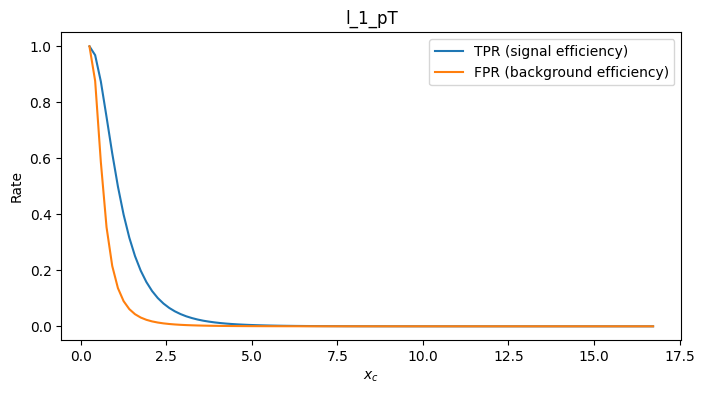

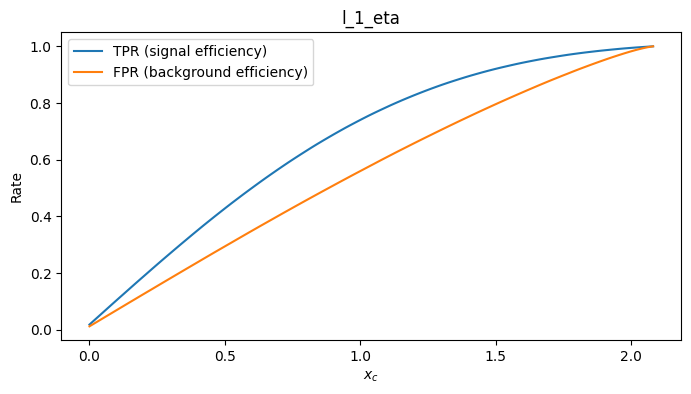

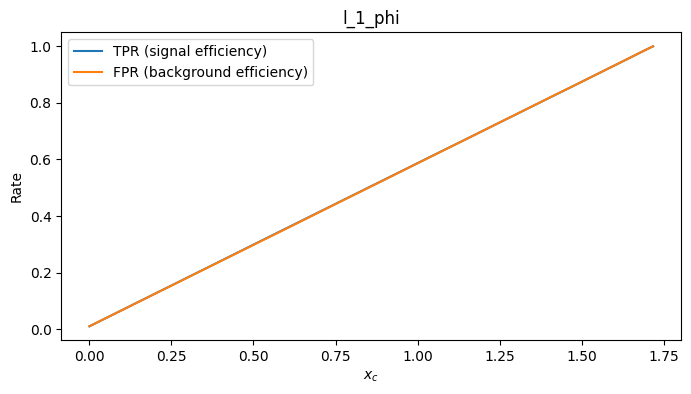

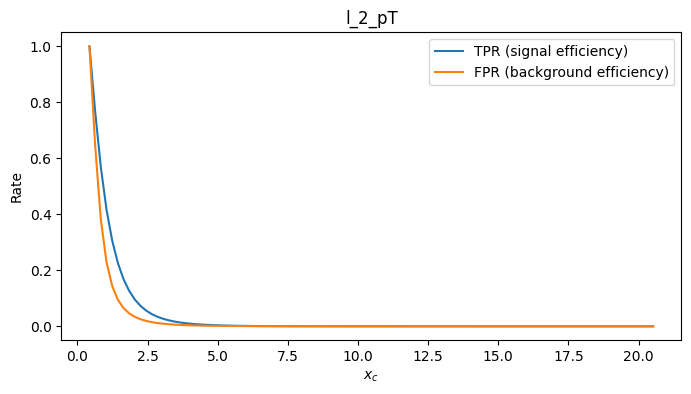

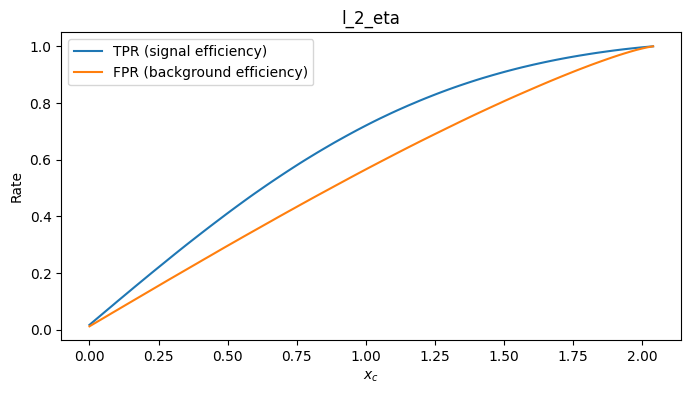

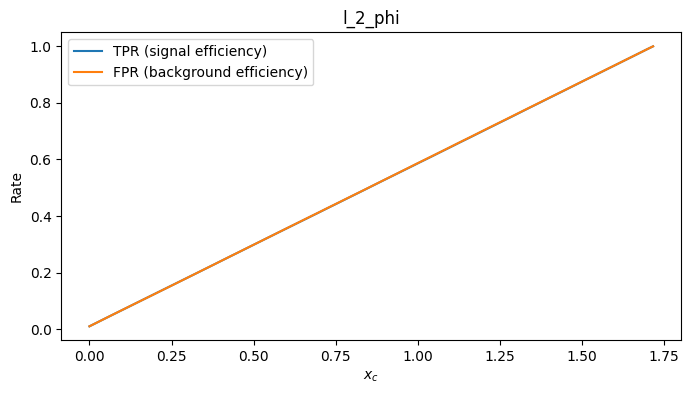

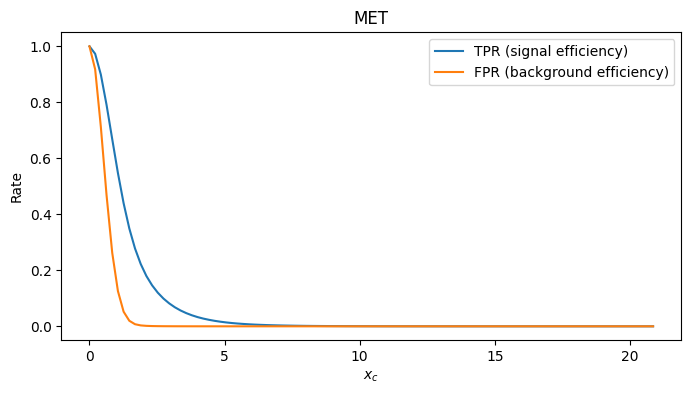

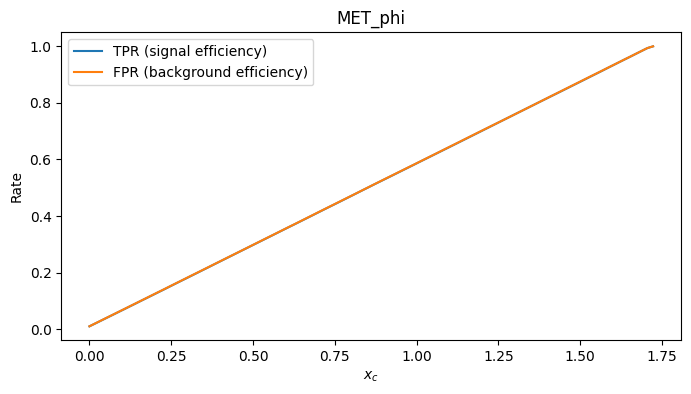

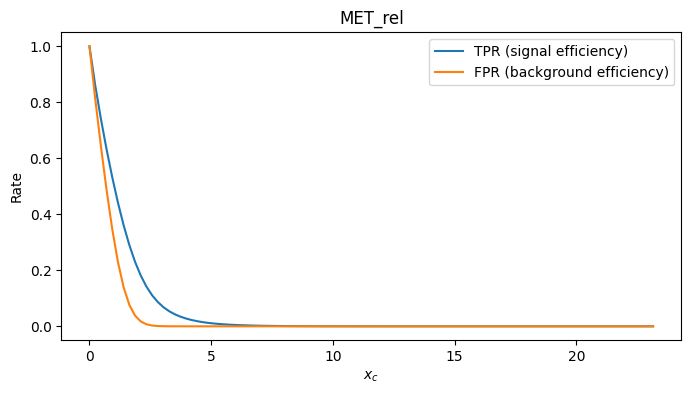

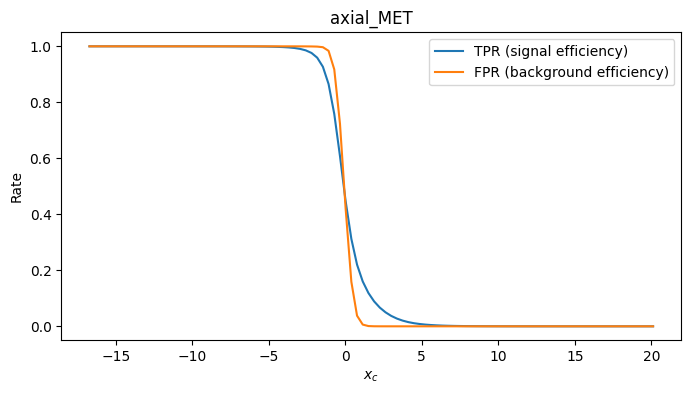

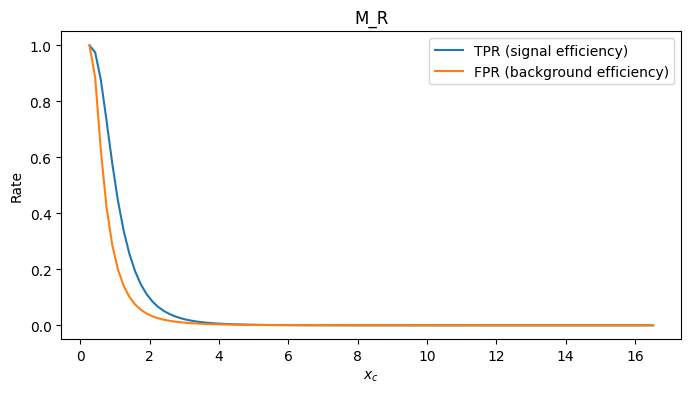

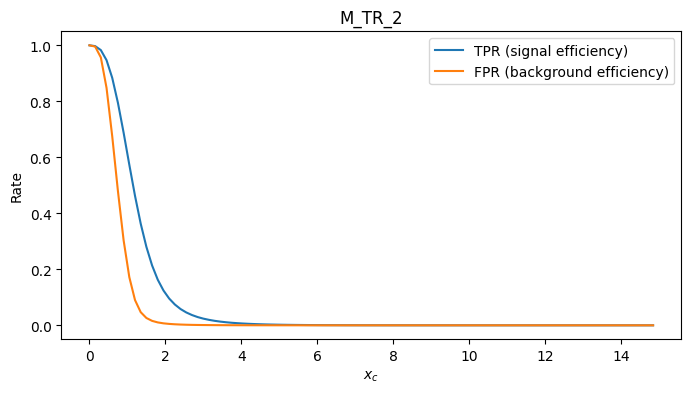

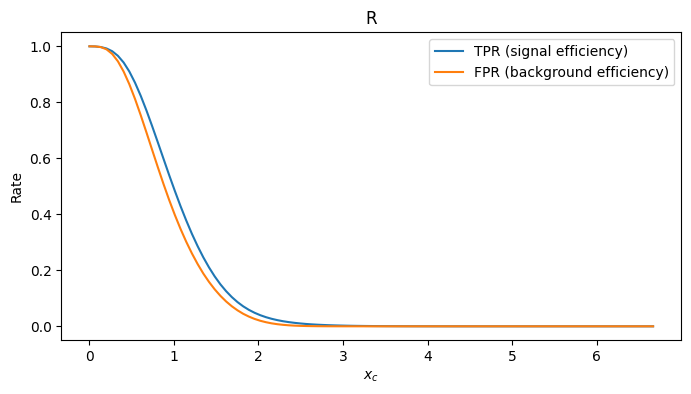

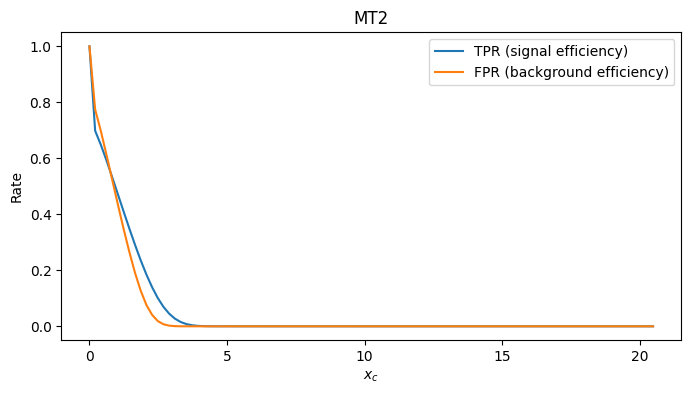

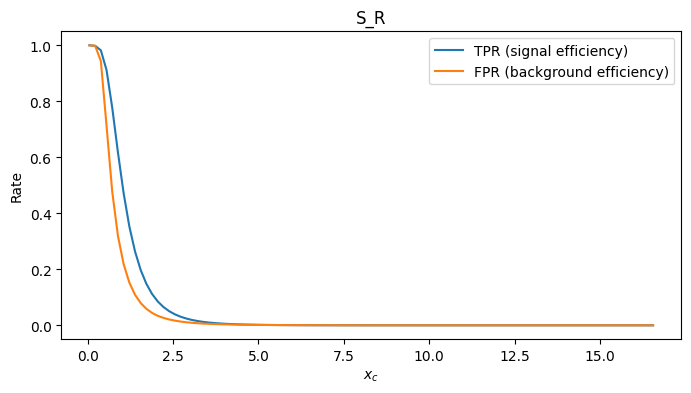

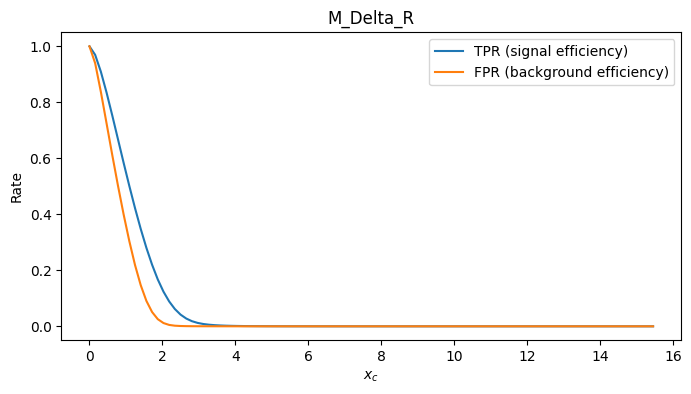

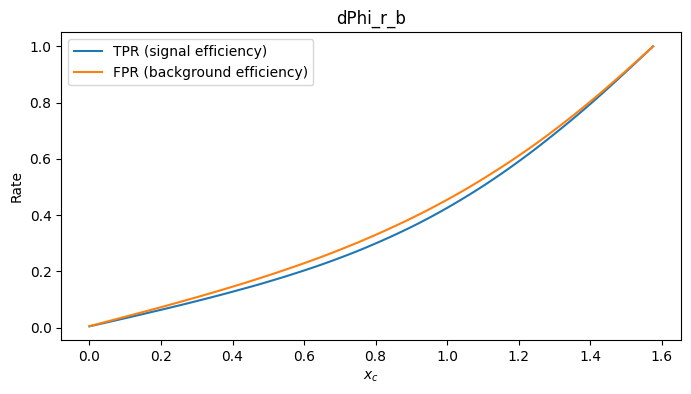

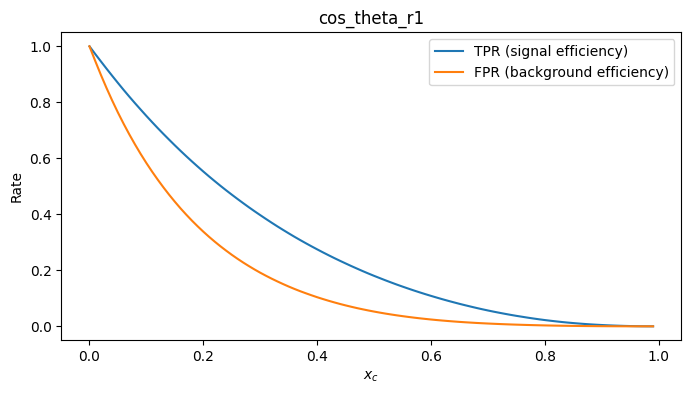

In [19]:
# compute_rate handles strategy 1 (cumulative from right, x > x_c)
# compute_rate_2 handles strategy 2 (cumulative from left, x < x_c)
# Strategy 4 first transforms variable to |x - mu| before computing cumulative sum

def compute_rate(d, bins=100):
    hist, bins_ = np.histogram(d, bins=bins, density=True)
    R = np.cumsum(hist[::-1])[::-1] * (bins_[1] - bins_[0])
    return R, bins_

def compute_rate_2(d, bins=100):
    hist, bins_ = np.histogram(d, bins=bins, density=True)
    R = np.cumsum(hist) * (bins_[1] - bins_[0])
    return R, bins_

for var in VarNames[1:]:
    strategy = selection_strategy[var]

    # Apply the correct rate computation based on selection strategy
    if strategy == 1:
        TPR, bins_ = compute_rate(df_sig[var])
        FPR, bins_ = compute_rate(df_bkg[var], bins=bins_)
    elif strategy == 2:
        TPR, bins_ = compute_rate_2(df_sig[var])
        FPR, bins_ = compute_rate_2(df_bkg[var], bins=bins_)
    elif strategy == 4:
        mu = df_sig[var].mean()
        TPR, bins_ = compute_rate_2(np.abs(df_sig[var] - mu))
        FPR, bins_ = compute_rate_2(np.abs(df_bkg[var] - mu), bins=bins_)

    plt.figure(figsize=(8, 4))
    plt.plot(bins_[:-1], TPR, label="TPR (signal efficiency)")
    plt.plot(bins_[:-1], FPR, label="FPR (background efficiency)")
    plt.xlabel("$x_c$")
    plt.ylabel("Rate")
    plt.title(var)
    plt.legend()
    plt.show()

l_1_pT


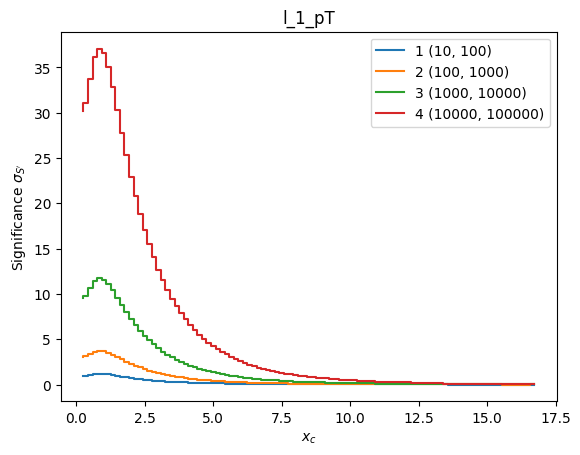

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.617711,0.21567,6.17711,21.567,1.17274,0.920654
2,100,1000,0.617711,0.21567,61.7711,215.67,3.70852,0.920654
3,1000,10000,0.617711,0.21567,617.711,2156.7,11.7274,0.920654
4,10000,100000,0.617711,0.21567,6177.11,21567,37.0852,0.920654


l_1_eta


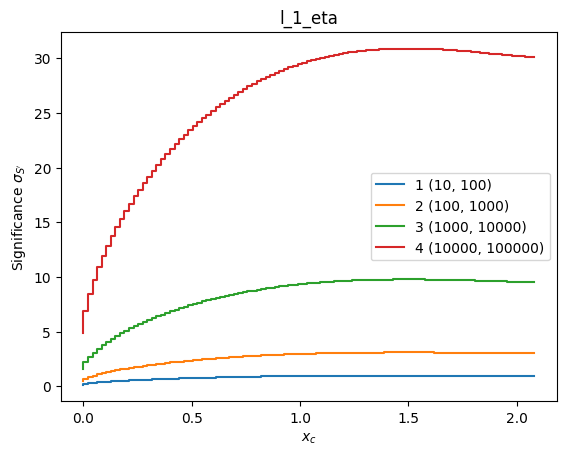

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.918749,0.792566,9.18749,79.2566,0.976927,1.49283
2,100,1000,0.918749,0.792566,91.8749,792.566,3.08932,1.49283
3,1000,10000,0.918749,0.792566,918.749,7925.66,9.76927,1.49283
4,10000,100000,0.918749,0.792566,9187.49,79256.6,30.8932,1.49283


l_1_phi


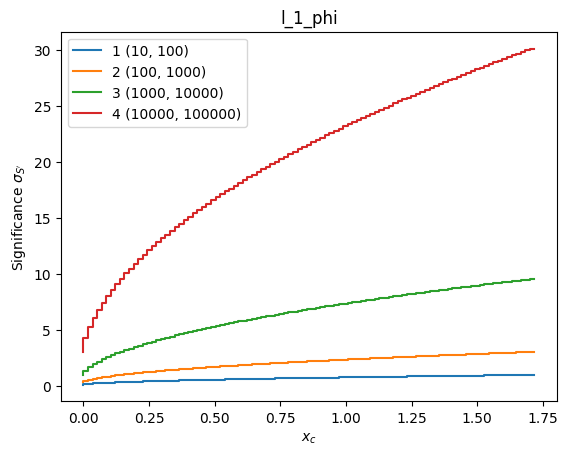

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,1,1,10,100,0.953463,1.71804
2,100,1000,1,1,100,1000,3.01511,1.71804
3,1000,10000,1,1,1000,10000,9.53463,1.71804
4,10000,100000,1,1,10000,100000,30.1511,1.71804


l_2_pT


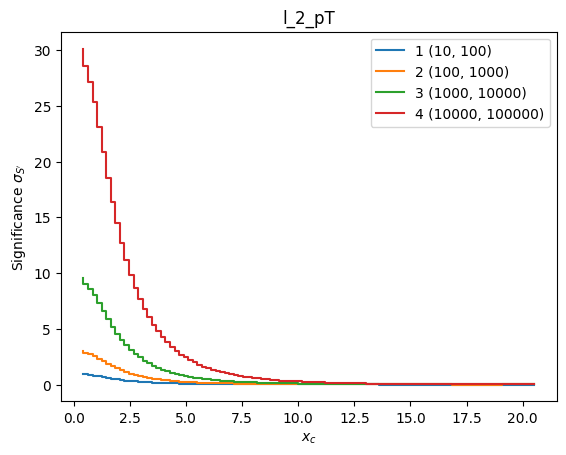

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,1,1,10,100,0.953463,0.428588
2,100,1000,1,1,100,1000,3.01511,0.428588
3,1000,10000,1,1,1000,10000,9.53463,0.428588
4,10000,100000,1,1,10000,100000,30.1511,0.428588


l_2_eta


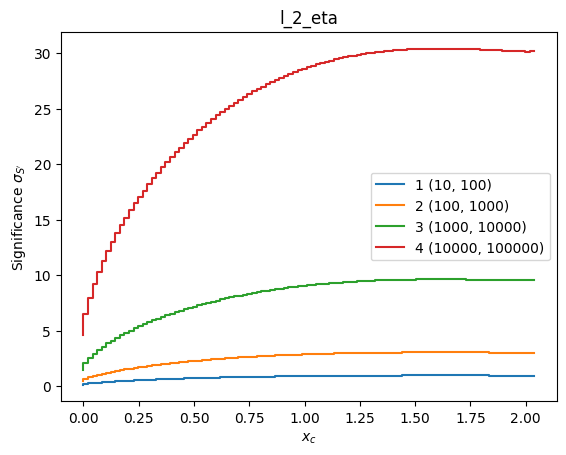

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.935388,0.852079,9.35388,85.2079,0.961909,1.60655
2,100,1000,0.935388,0.852079,93.5388,852.079,3.04182,1.60655
3,1000,10000,0.935388,0.852079,935.388,8520.79,9.61909,1.60655
4,10000,100000,0.935388,0.852079,9353.88,85207.9,30.4182,1.60655


l_2_phi


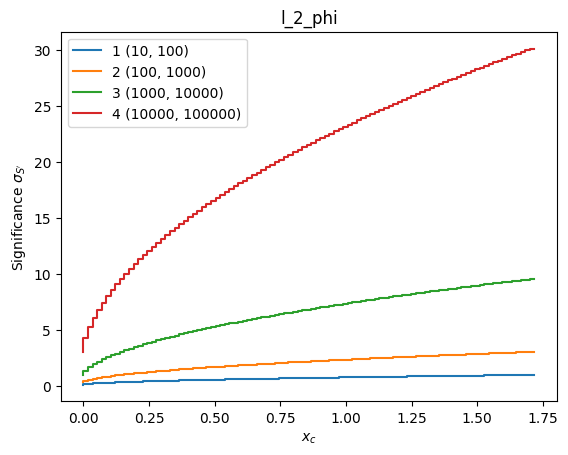

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,1,1,10,100,0.953463,1.71747
2,100,1000,1,1,100,1000,3.01511,1.71747
3,1000,10000,1,1,1000,10000,9.53463,1.71747
4,10000,100000,1,1,10000,100000,30.1511,1.71747


MET


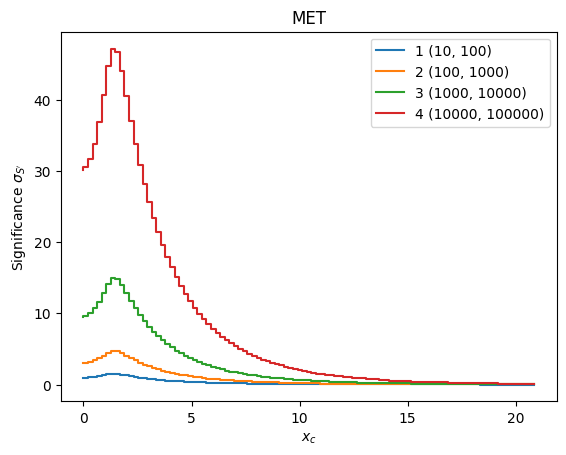

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.349463,0.0198365,3.49463,1.98365,1.49307,1.47506
2,100,1000,0.349463,0.0198365,34.9463,19.8365,4.72149,1.47506
3,1000,10000,0.349463,0.0198365,349.463,198.365,14.9307,1.47506
4,10000,100000,0.349463,0.0198365,3494.63,1983.65,47.2149,1.47506


MET_phi


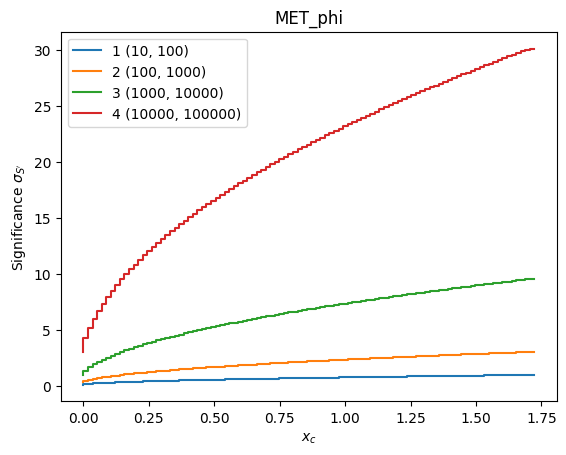

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,1,1,10,100,0.953463,1.72313
2,100,1000,1,1,100,1000,3.01511,1.72313
3,1000,10000,1,1,1000,10000,9.53463,1.72313
4,10000,100000,1,1,10000,100000,30.1511,1.72313


MET_rel


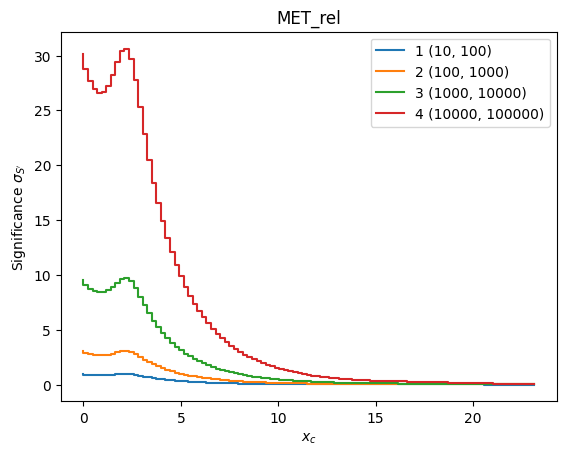

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.142159,0.00731554,1.42159,0.731554,0.96881,2.33864
2,100,1000,0.142159,0.00731554,14.2159,7.31554,3.06365,2.33864
3,1000,10000,0.142159,0.00731554,142.159,73.1554,9.6881,2.33864
4,10000,100000,0.142159,0.00731554,1421.59,731.554,30.6365,2.33864


axial_MET


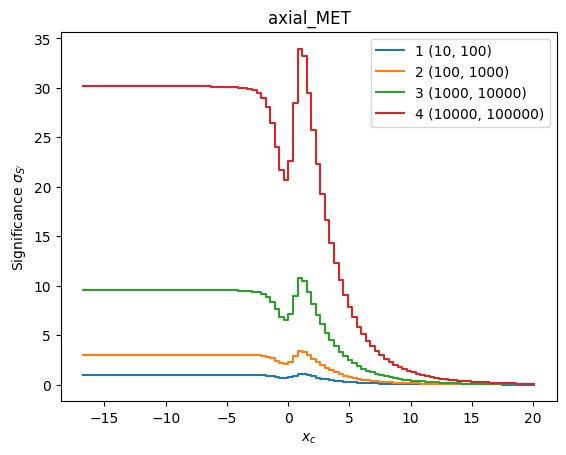

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.160196,0.00620536,1.60196,0.620536,1.07456,1.1405
2,100,1000,0.160196,0.00620536,16.0196,6.20536,3.39806,1.1405
3,1000,10000,0.160196,0.00620536,160.196,62.0536,10.7456,1.1405
4,10000,100000,0.160196,0.00620536,1601.96,620.536,33.9806,1.1405


M_R


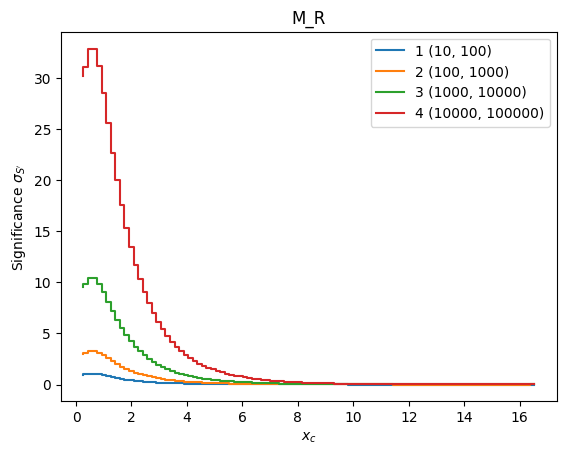

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.731022,0.421495,7.31022,42.1495,1.03945,0.76074
2,100,1000,0.731022,0.421495,73.1022,421.495,3.28704,0.76074
3,1000,10000,0.731022,0.421495,731.022,4214.95,10.3945,0.76074
4,10000,100000,0.731022,0.421495,7310.22,42149.5,32.8704,0.76074


M_TR_2


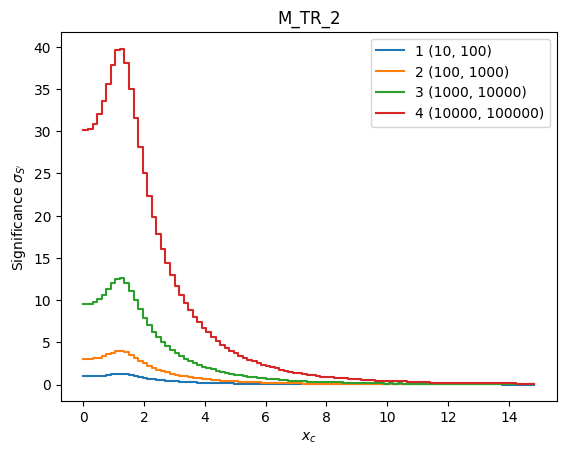

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.363213,0.0469801,3.63213,4.69801,1.25845,1.35029
2,100,1000,0.363213,0.0469801,36.3213,46.9801,3.97956,1.35029
3,1000,10000,0.363213,0.0469801,363.213,469.801,12.5845,1.35029
4,10000,100000,0.363213,0.0469801,3632.13,4698.01,39.7956,1.35029


R


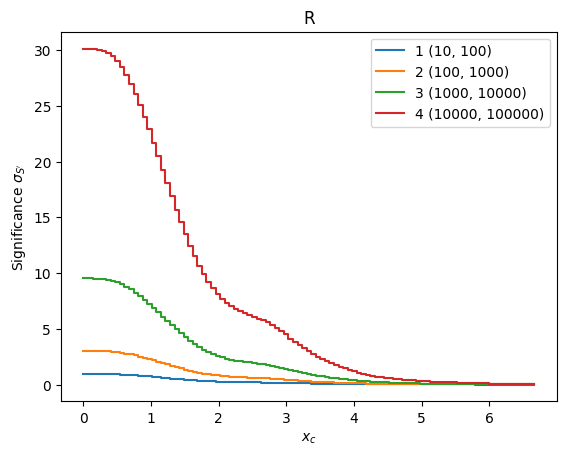

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,1,1,10,100,0.953463,0.00204808
2,100,1000,1,1,100,1000,3.01511,0.00204808
3,1000,10000,1,1,1000,10000,9.53463,0.00204808
4,10000,100000,1,1,10000,100000,30.1511,0.00204808


MT2


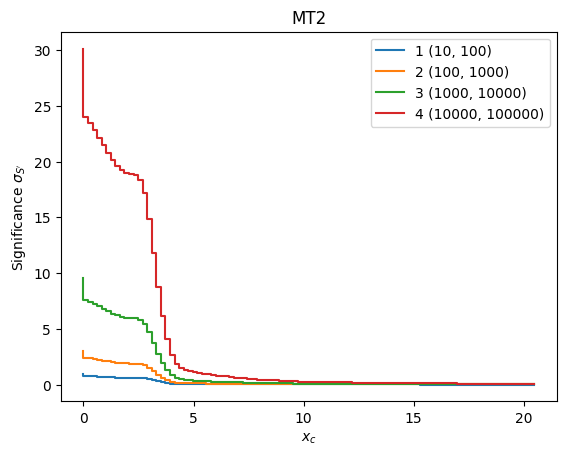

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,1,1,10,100,0.953463,0
2,100,1000,1,1,100,1000,3.01511,0
3,1000,10000,1,1,1000,10000,9.53463,0
4,10000,100000,1,1,10000,100000,30.1511,0


S_R


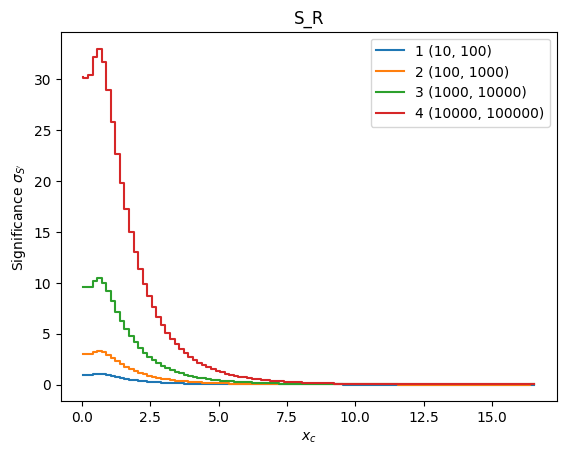

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.777207,0.477283,7.77207,47.7283,1.04325,0.719131
2,100,1000,0.777207,0.477283,77.7207,477.283,3.29905,0.719131
3,1000,10000,0.777207,0.477283,777.207,4772.83,10.4325,0.719131
4,10000,100000,0.777207,0.477283,7772.07,47728.3,32.9905,0.719131


M_Delta_R


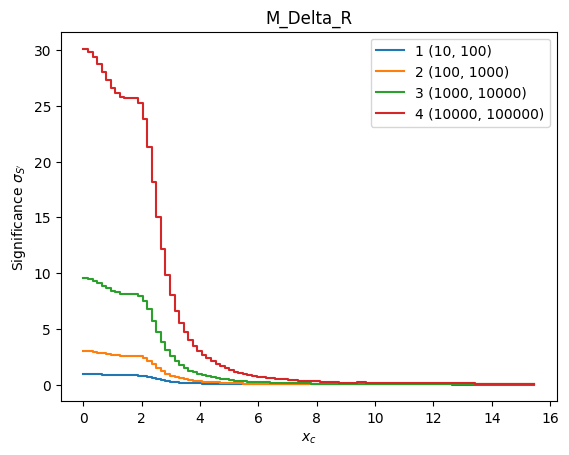

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,1,1,10,100,0.953463,0.00445562
2,100,1000,1,1,100,1000,3.01511,0.00445562
3,1000,10000,1,1,1000,10000,9.53463,0.00445562
4,10000,100000,1,1,10000,100000,30.1511,0.00445562


dPhi_r_b


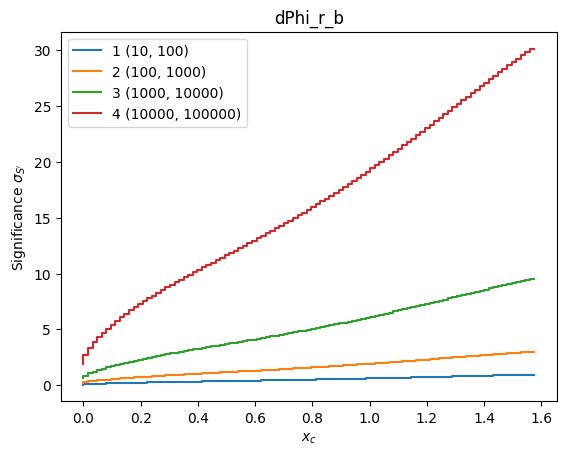

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,1,1,10,100,0.953463,1.57574
2,100,1000,1,1,100,1000,3.01511,1.57574
3,1000,10000,1,1,1000,10000,9.53463,1.57574
4,10000,100000,1,1,10000,100000,30.1511,1.57574


cos_theta_r1


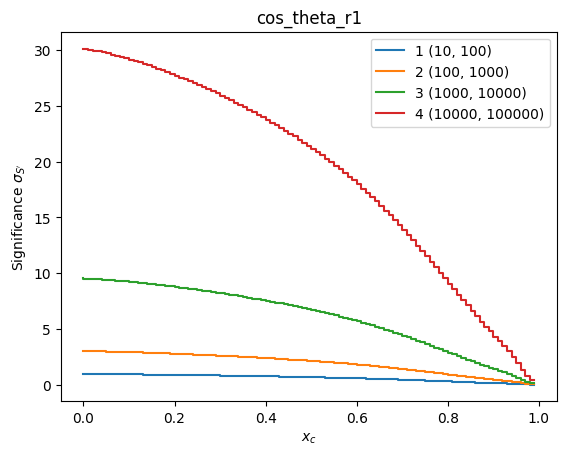

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,1,1,10,100,0.953463,1.50257e-07
2,100,1000,1,1,100,1000,3.01511,1.50257e-07
3,1000,10000,1,1,1000,10000,9.53463,1.50257e-07
4,10000,100000,1,1,10000,100000,30.1511,1.50257e-07


In [20]:
# Significance is sigma = N'_S / sqrt(N'_S + N'_B), where N'_S,B = TPR/FPR * N_S,B
# The optimal x_c and corresponding values are reported in a table below each plot

scenarios = {
    "1": (10,    100),
    "2": (100,   1000),
    "3": (1000,  10000),
    "4": (10000, 100000),
}

def compare_significance(df_sig, df_bkg, obs_name, scenarios, strategy=1, bins=100, log=False):
    mu = df_sig[obs_name].mean()

    # Compute TPR and FPR using appropriate strategy
    if strategy == 1:
        TPR, bins_ = compute_rate(df_sig[obs_name], bins=bins)
        FPR, bins_ = compute_rate(df_bkg[obs_name], bins=bins_)
    elif strategy == 2:
        TPR, bins_ = compute_rate_2(df_sig[obs_name], bins=bins)
        FPR, bins_ = compute_rate_2(df_bkg[obs_name], bins=bins_)
    elif strategy == 4:
        TPR, bins_ = compute_rate_2(np.abs(df_sig[obs_name] - mu), bins=bins)
        FPR, bins_ = compute_rate_2(np.abs(df_bkg[obs_name] - mu), bins=bins_)

    table = []
    for name, (n_sig_expected, n_bkg_expected) in scenarios.items():
        n_sig_prime = n_sig_expected * TPR
        n_bkg_prime = n_bkg_expected * FPR
        sig = n_sig_prime / np.sqrt(n_sig_prime + n_bkg_prime)
        plt.step(bins_[:-1], sig, label=name + " " + str((n_sig_expected, n_bkg_expected)))

        # Record the x_c that maximizes significance for each scenario
        max_i = np.argmax(sig)
        table.append((name, n_sig_expected, n_bkg_expected,
                      TPR[max_i], FPR[max_i],
                      n_sig_prime[max_i], n_bkg_prime[max_i],
                      sig[max_i], bins_[max_i]))

    if log:
        plt.yscale("log")
    plt.xlabel("$x_c$")
    plt.ylabel("Significance $\\sigma_{S'}$")
    plt.title(obs_name)
    plt.legend()
    plt.show()

    display(HTML(tabulate.tabulate(table, tablefmt='html',
                                   headers=["Scenario", "N_S", "N_B", "TPR", "FPR",
                                            "N_S'", "N_B'", "sig", "x_c"])))

for var in VarNames[1:]:
    print(var)
    compare_significance(df_sig, df_bkg, var, scenarios, strategy=selection_strategy[var])

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [23]:
# Exercise 6.1: Choose 3 observables and cut values based on significance peaks from 5.3

selected_cuts = {
    "M_TR_2":    ("gt", 1.35),
    "M_Delta_R": ("gt", 2.0),
    "S_R":       ("gt", 0.3),
}

In [24]:
# Exercise 6.2: Successively apply each cut and record eps_S, eps_B, N'_S, N'_B, sigma

scenarios = {
    "1": (10,    100),
    "2": (100,   1000),
    "3": (1000,  10000),
    "4": (10000, 100000),
}

for scenario_name, (N_S, N_B) in scenarios.items():
    print(f"\nScenario {scenario_name}: N_S={N_S}, N_B={N_B}")
    
    df_sig_cut = df_sig.copy()
    df_bkg_cut = df_bkg.copy()
    table = []

    for obs, (direction, xc) in selected_cuts.items():
        if direction == "gt":
            df_sig_cut = df_sig_cut[df_sig_cut[obs] > xc]
            df_bkg_cut = df_bkg_cut[df_bkg_cut[obs] > xc]

        eps_s = df_sig_cut.shape[0] / df_sig.shape[0]
        eps_b = df_bkg_cut.shape[0] / df_bkg.shape[0]
        N_s_prime = eps_s * N_S
        N_b_prime = eps_b * N_B
        sig = N_s_prime / np.sqrt(N_s_prime + N_b_prime)

        table.append((obs + f" > {xc}", f"{eps_s:.4f}", f"{eps_b:.4f}",
                      f"{N_s_prime:.2f}", f"{N_b_prime:.2f}", f"{sig:.3f}"))

    display(HTML(tabulate.tabulate(table, tablefmt='html',
                                   headers=["Cut", "eps_S", "eps_B", "N'_S", "N'_B", "sigma"])))


Scenario 1: N_S=10, N_B=100


Cut,eps_S,eps_B,N'_S,N'_B,sigma
M_TR_2 > 1.35,0.3634,0.047,3.63,4.7,1.259
M_Delta_R > 2.0,0.1232,0.0098,1.23,0.98,0.828
S_R > 0.3,0.1232,0.0098,1.23,0.98,0.828



Scenario 2: N_S=100, N_B=1000


Cut,eps_S,eps_B,N'_S,N'_B,sigma
M_TR_2 > 1.35,0.3634,0.047,36.34,47.04,3.98
M_Delta_R > 2.0,0.1232,0.0098,12.32,9.8,2.62
S_R > 0.3,0.1232,0.0098,12.32,9.8,2.62



Scenario 3: N_S=1000, N_B=10000


Cut,eps_S,eps_B,N'_S,N'_B,sigma
M_TR_2 > 1.35,0.3634,0.047,363.4,470.36,12.585
M_Delta_R > 2.0,0.1232,0.0098,123.23,98.02,8.285
S_R > 0.3,0.1232,0.0098,123.23,98.02,8.285



Scenario 4: N_S=10000, N_B=100000


Cut,eps_S,eps_B,N'_S,N'_B,sigma
M_TR_2 > 1.35,0.3634,0.047,3634,4703.65,39.798
M_Delta_R > 2.0,0.1232,0.0098,1232.32,980.17,26.199
S_R > 0.3,0.1232,0.0098,1232.32,980.17,26.199


M_Delta_R BEFORE M_TR_2 cut:


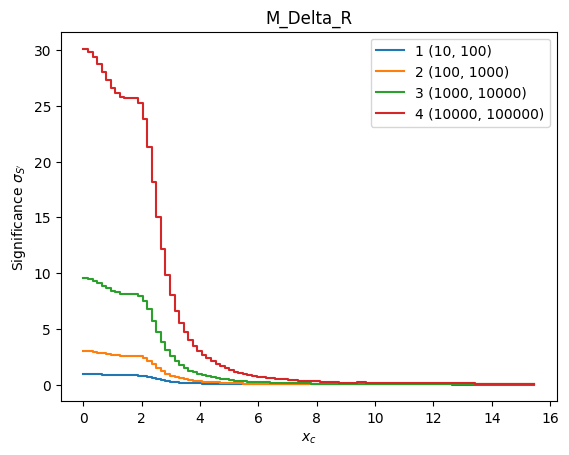

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,1,1,10,100,0.953463,0.00445562
2,100,1000,1,1,100,1000,3.01511,0.00445562
3,1000,10000,1,1,1000,10000,9.53463,0.00445562
4,10000,100000,1,1,10000,100000,30.1511,0.00445562


M_Delta_R AFTER M_TR_2 cut:


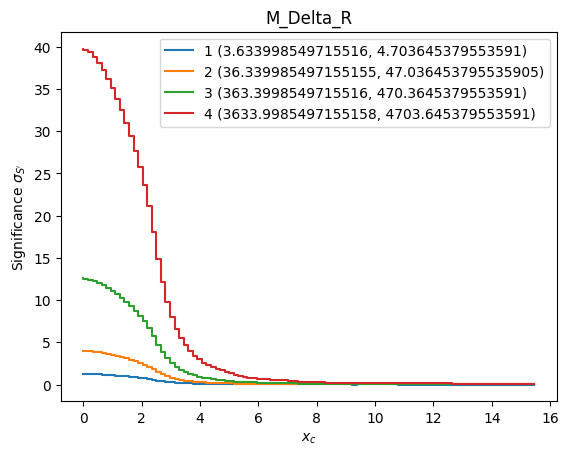

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,3.634,4.70365,1,1,3.634,4.70365,1.25853,0.00448977
2,36.34,47.0365,1,1,36.34,47.0365,3.97982,0.00448977
3,363.4,470.365,1,1,363.4,470.365,12.5853,0.00448977
4,3634,4703.65,1,1,3634,4703.65,39.7982,0.00448977


M_TR_2 BEFORE M_Delta_R cut:


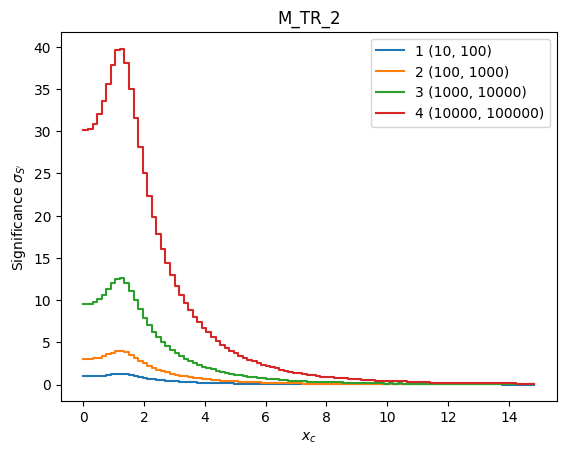

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.363213,0.0469801,3.63213,4.69801,1.25845,1.35029
2,100,1000,0.363213,0.0469801,36.3213,46.9801,3.97956,1.35029
3,1000,10000,0.363213,0.0469801,363.213,469.801,12.5845,1.35029
4,10000,100000,0.363213,0.0469801,3632.13,4698.01,39.7956,1.35029


M_TR_2 AFTER M_Delta_R cut:


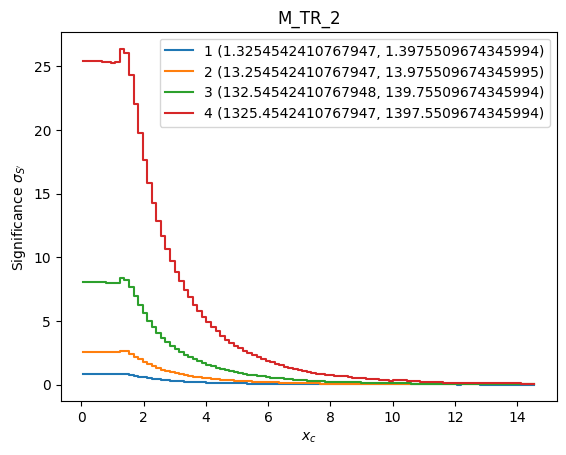

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,1.32545,1.39755,0.90591,0.621613,1.20074,0.868736,0.834679,1.38192
2,13.2545,13.9755,0.90591,0.621613,12.0074,8.68736,2.63949,1.38192
3,132.545,139.755,0.90591,0.621613,120.074,86.8736,8.34679,1.38192
4,1325.45,1397.55,0.90591,0.621613,1200.74,868.736,26.3949,1.38192


In [25]:
# Exercise 6.3: M_TR_2 and M_Delta_R are correlated, so cut order can affect results
# Cut on M_TR_2 first, then re-optimize on M_Delta_R
xc_MTR2 = 1.35
df_sig_1 = df_sig[df_sig["M_TR_2"] > xc_MTR2]
df_bkg_1 = df_bkg[df_bkg["M_TR_2"] > xc_MTR2]

eff_s = df_sig_1.shape[0] / df_sig.shape[0]
eff_b = df_bkg_1.shape[0] / df_bkg.shape[0]

# Rescale scenarios to reflect reduced sample after first cut
scenarios_1 = dict(zip(scenarios.keys(),
                   map(lambda x: (eff_s * x[0], eff_b * x[1]), scenarios.values())))

print("M_Delta_R BEFORE M_TR_2 cut:")
_= compare_significance(df_sig, df_bkg, "M_Delta_R", scenarios, strategy=1)

print("M_Delta_R AFTER M_TR_2 cut:")
_= compare_significance(df_sig_1, df_bkg_1, "M_Delta_R", scenarios_1, strategy=1)

# Reverse order — cut on M_Delta_R first, then re-optimize on M_TR_2
xc_MDR = 2.0
df_sig_2 = df_sig[df_sig["M_Delta_R"] > xc_MDR]
df_bkg_2 = df_bkg[df_bkg["M_Delta_R"] > xc_MDR]

eff_s2 = df_sig_2.shape[0] / df_sig.shape[0]
eff_b2 = df_bkg_2.shape[0] / df_bkg.shape[0]

scenarios_2 = dict(zip(scenarios.keys(),
                   map(lambda x: (eff_s2 * x[0], eff_b2 * x[1]), scenarios.values())))

print("M_TR_2 BEFORE M_Delta_R cut:")
_= compare_significance(df_sig, df_bkg, "M_TR_2", scenarios, strategy=1)

print("M_TR_2 AFTER M_Delta_R cut:")
_= compare_significance(df_sig_2, df_bkg_2, "M_TR_2", scenarios_2, strategy=1)

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



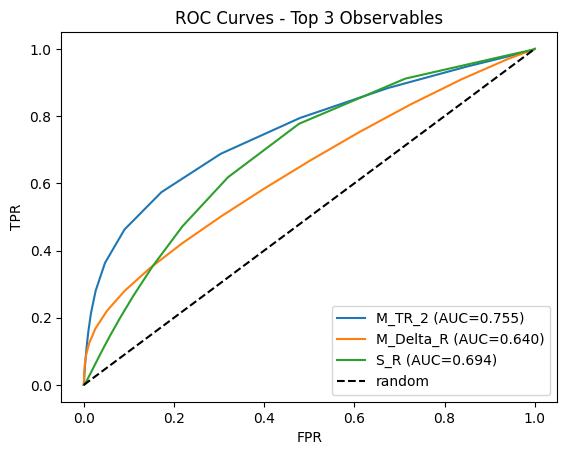

In [26]:
# Exercise 7.1: Overlay ROC curves for top 3 observables, with AUC in the legend
# AUC computed using trapezoid rule from lecture 17

def AUC(TPR, FPR):
    n = FPR.shape[0]
    return np.sum((FPR[0:n-1] - FPR[1:]) * (TPR[0:n-1] + TPR[1:]) / 2)

top_obs = ["M_TR_2", "M_Delta_R", "S_R"]

for obs in top_obs:
    TPR, bins_ = compute_rate(df_sig[obs])
    FPR, bins_ = compute_rate(df_bkg[obs], bins=bins_)
    auc = AUC(TPR, FPR)
    plt.plot(FPR, TPR, label=f"{obs} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="random")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curves - Top 3 Observables")
plt.legend()
plt.show()

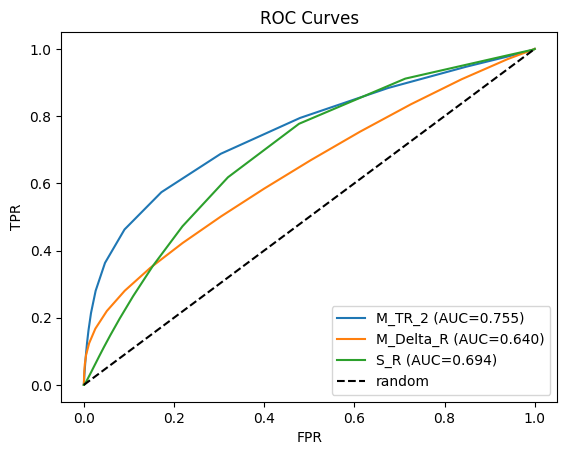

In [27]:
# Exercise 7.2: Generalized function to plot ROC curves for any set of observables

def plot_roc(df_sig, df_bkg, obs_list, title="ROC Curves"):
    for obs in obs_list:
        strategy = selection_strategy[obs]
        mu = df_sig[obs].mean()

        if strategy == 1:
            TPR, bins_ = compute_rate(df_sig[obs])
            FPR, bins_ = compute_rate(df_bkg[obs], bins=bins_)
        elif strategy == 2:
            TPR, bins_ = compute_rate_2(df_sig[obs])
            FPR, bins_ = compute_rate_2(df_bkg[obs], bins=bins_)
        elif strategy == 4:
            TPR, bins_ = compute_rate_2(np.abs(df_sig[obs] - mu))
            FPR, bins_ = compute_rate_2(np.abs(df_bkg[obs] - mu), bins=bins_)

        auc = AUC(TPR, FPR)
        plt.plot(FPR, TPR, label=f"{obs} (AUC={auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', label="random")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend()
    plt.show()

# Test with top 3 observables
plot_roc(df_sig, df_bkg, top_obs)

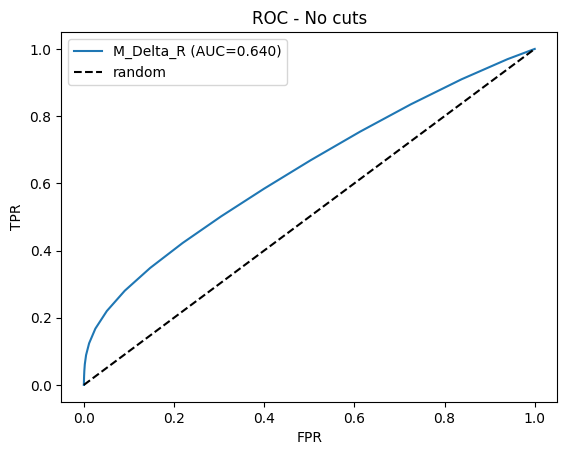

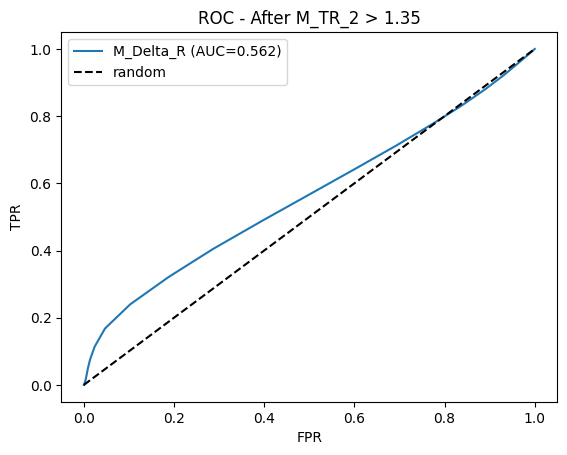

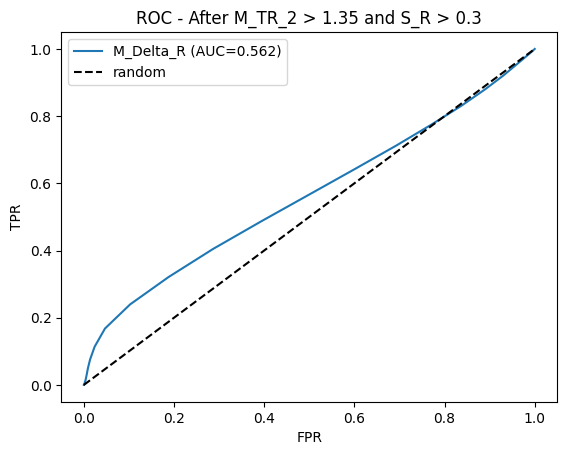

In [28]:
# Exercise 7.3: Plot ROC curve after each successive cut from Exercise 6
# Each curve shows how the discriminating power of M_Delta_R changes as cuts are applied

# No cuts applied yet
plot_roc(df_sig, df_bkg, ["M_Delta_R"], title="ROC - No cuts")

# After M_TR_2 cut
df_sig_c1 = df_sig[df_sig["M_TR_2"] > 1.35]
df_bkg_c1 = df_bkg[df_bkg["M_TR_2"] > 1.35]
plot_roc(df_sig_c1, df_bkg_c1, ["M_Delta_R"], title="ROC - After M_TR_2 > 1.35")

# After M_TR_2 and S_R cuts
df_sig_c2 = df_sig_c1[df_sig_c1["S_R"] > 0.3]
df_bkg_c2 = df_bkg_c1[df_bkg_c1["S_R"] > 0.3]
plot_roc(df_sig_c2, df_bkg_c2, ["M_Delta_R"], title="ROC - After M_TR_2 > 1.35 and S_R > 0.3")

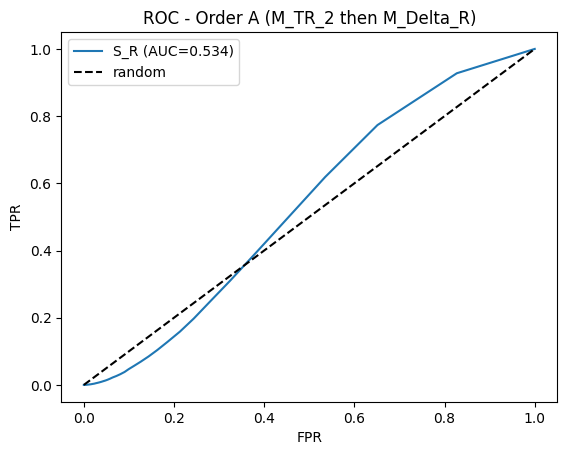

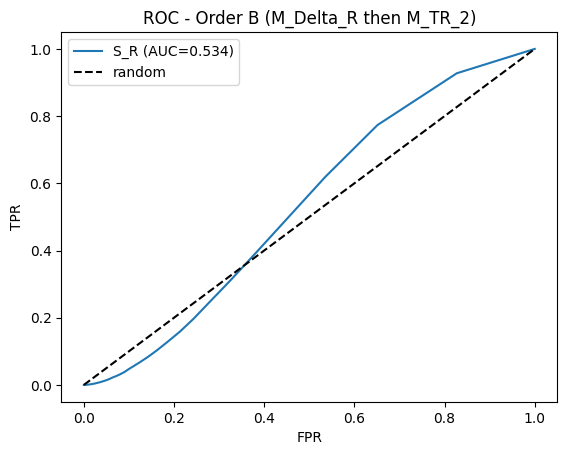

In [29]:
# Exercise 7.4: Demonstrate effect of changing cut order using the plot_roc function

# Order A: M_TR_2 then M_Delta_R
df_sig_A = df_sig[df_sig["M_TR_2"] > 1.35]
df_bkg_A = df_bkg[df_bkg["M_TR_2"] > 1.35]
df_sig_A = df_sig_A[df_sig_A["M_Delta_R"] > 2.0]
df_bkg_A = df_bkg_A[df_bkg_A["M_Delta_R"] > 2.0]

# Order B: M_Delta_R then M_TR_2
df_sig_B = df_sig[df_sig["M_Delta_R"] > 2.0]
df_bkg_B = df_bkg[df_bkg["M_Delta_R"] > 2.0]
df_sig_B = df_sig_B[df_sig_B["M_TR_2"] > 1.35]
df_bkg_B = df_bkg_B[df_bkg_B["M_TR_2"] > 1.35]

# Since we apply both cuts either way, the final datasets should be identical
plot_roc(df_sig_A, df_bkg_A, ["S_R"], title="ROC - Order A (M_TR_2 then M_Delta_R)")
plot_roc(df_sig_B, df_bkg_B, ["S_R"], title="ROC - Order B (M_Delta_R then M_TR_2)")

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [30]:
# Exercise 8.1: Compute between-class S_B and within-class S_W covariance matrices
# Drop the signal label first so we don't cheat by including ground truth

df_sig_0 = df_sig.drop("signal", axis=1)
df_bkg_0 = df_bkg.drop("signal", axis=1)

# Compute class means and delta = m_s - m_b
m_s = np.mean(df_sig_0, axis=0)
m_b = np.mean(df_bkg_0, axis=0)
delta = np.matrix(m_s - m_b).transpose()

# S_B = delta * delta^T (outer product)
S_B = delta * delta.transpose()
print("S_B shape:", S_B.shape)

# S_W = sum of (x - m)(x - m)^T for signal and background
delta_s = np.matrix(df_sig_0 - m_s).transpose()
delta_b = np.matrix(df_bkg_0 - m_b).transpose()

S_W_s = delta_s * delta_s.transpose()
S_W_b = delta_b * delta_b.transpose()
S_W = S_W_s + S_W_b
print("S_W shape:", S_W.shape)

S_B shape: (18, 18)
S_W shape: (18, 18)


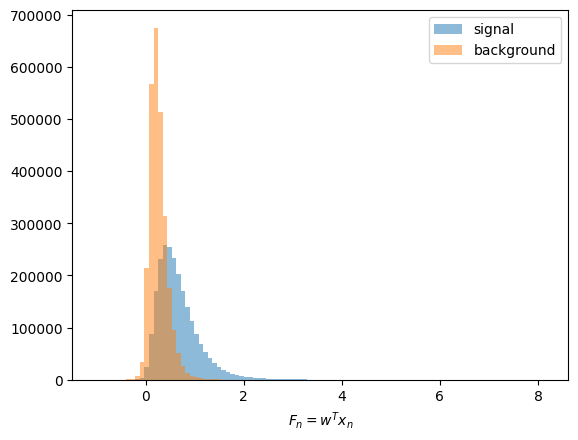

In [31]:
# Exercise 8.2: Compute linear coefficients w = S_W^-1 * (m_s - m_b)
# Then compare signal/background distributions of the discriminant output F = w^T * x

S_W_inv = np.linalg.inv(S_W)
w = S_W_inv * np.matrix(m_b - m_s).transpose()

# Normalize weights
w_1 = w / sum(w)

# Apply discriminant to signal and background
output_s = np.matrix(df_sig_0) * w_1
output_b = np.matrix(df_bkg_0) * w_1

h_s, bins, _ = plt.hist(output_s, label="signal", alpha=0.5, bins=100)
h_b, bins, _ = plt.hist(output_b, bins=bins, alpha=0.5, label="background")
plt.xlabel("$F_n = w^T x_n$")
plt.legend()
plt.show()

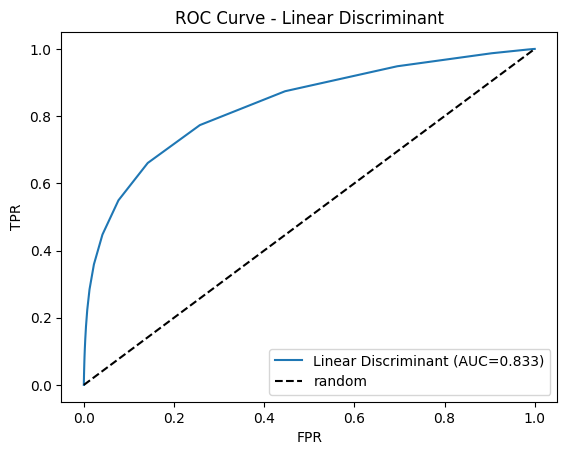

In [32]:
# Exercise 8.3: Draw the ROC curve for the linear discriminant output F_n

TPR_ld, bins_ = compute_rate(np.array(output_s).flatten())
FPR_ld, bins_ = compute_rate(np.array(output_b).flatten(), bins=bins_)

auc_ld = AUC(TPR_ld, FPR_ld)

plt.plot(FPR_ld, TPR_ld, label=f"Linear Discriminant (AUC={auc_ld:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="random")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Linear Discriminant")
plt.legend()
plt.show()

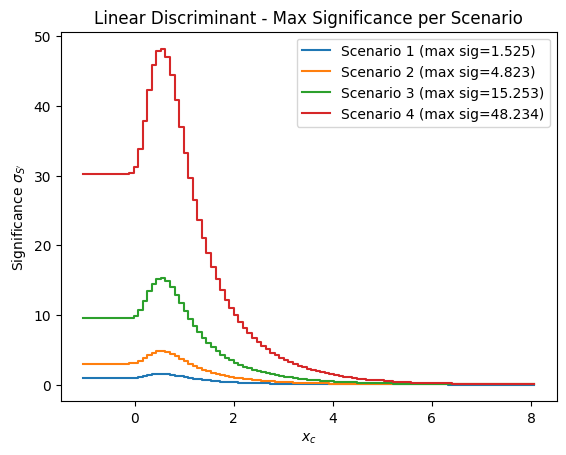

In [33]:
# Exercise 8.4: Find the maximum significance achievable with the linear discriminant
# across all 4 scenarios, using the same approach as Exercise 5.3

for scenario_name, (N_S, N_B) in scenarios.items():
    n_sig_prime = N_S * TPR_ld
    n_bkg_prime = N_B * FPR_ld
    sig = n_sig_prime / np.sqrt(n_sig_prime + n_bkg_prime)
    max_i = np.argmax(sig)
    plt.step(bins_[:-1], sig, label=f"Scenario {scenario_name} (max sig={sig[max_i]:.3f})")

plt.xlabel("$x_c$")
plt.ylabel("Significance $\\sigma_{S'}$")
plt.title("Linear Discriminant - Max Significance per Scenario")
plt.legend()
plt.show()